Description of approach:



*   First, I found the max degrees each predictor can take in the poly() function, then looped through each degree to find, when predicting default_rate alone, gave the highest Rsquared

* Then, i experimented with interactions, log(), and sqrt() terms above and beyond poly

* I found that interaction terms worked well, so I used more loop logic to run through all possible combinations of interaction terms with the predictors, excluding useless categoricals like name, city, state, etc

* After this, I learned that there are more than just 2-termed interations, and you can have infinitely termed interactions. So, I made a loop to run through combinations of 3-way interaction terms, and added ones that improved the Rsquared.

* I experimented by myself for a little bit, and learned that the loop wasn't the best: after some tweaking, I learned that removing predictors could also strengthen the Rsquared, maybe because of overfitting. So, I created a new section after adding interaction terms to trim off which ever interaction terms hurt the Rsquared. I did this by looping through the model formula, and iteratively removing terms to see whether the Rsquared went up.

* I added interaction terms all the way up to 6-way interactions, and trimmed after each addition of interactions.

* Thus, I ended up with an Rsquared of 0.88. I also noticed that the improvements were slowing down, so I also doubt that adding 7-way interactions would have significantly improved the Rsquared. Either way, my formula was rather long by the end.

* **SEE LAST CELL FOR FINAL MODEL**




In [ ]:
# split and seed

dat <- read.csv('https://skewthescript.org/s/four_year_colleges.csv', stringsAsFactors = FALSE)

train_size <- floor(0.8 * nrow(dat))

set.seed(2025)
train_ind <- sample(seq_len(nrow(dat)), size = train_size)

train <- dat[train_ind, ]
test  <- dat[-train_ind, ]

# Data Visualization

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



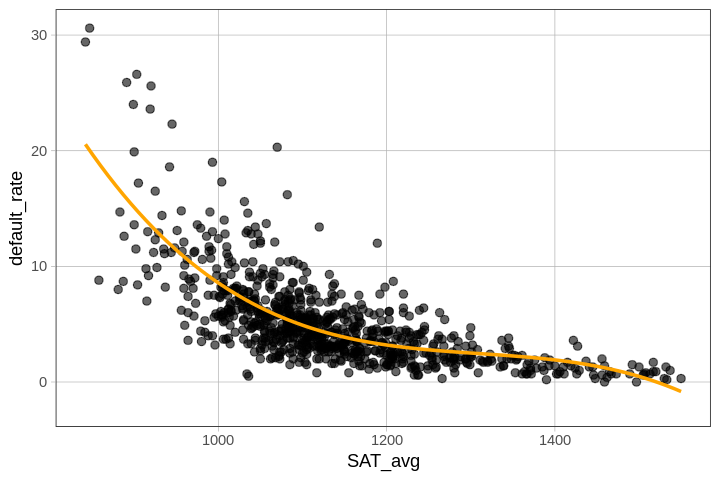

In [ ]:
install.packages("coursekata")
library(coursekata)
gf_point(data=train, default_rate ~ SAT_avg) %>% gf_lm(formula = y ~ poly(x, 3), color="orange")

In [ ]:
colnames(dat)

[1] "OPEID"                   "name"                   
 [3] "city"                    "state"                  
 [5] "region"                  "median_debt"            
 [7] "default_rate"            "highest_degree"         
 [9] "ownership"               "locale"                 
[11] "hbcu"                    "admit_rate"             
[13] "SAT_avg"                 "online_only"            
[15] "enrollment"              "net_price"              
[17] "avg_cost"                "net_tuition"            
[19] "ed_spending_per_student" "avg_faculty_salary"     
[21] "pct_PELL"                "pct_fed_loan"           
[23] "grad_rate"               "pct_firstgen"           
[25] "med_fam_income"          "med_alum_earnings"

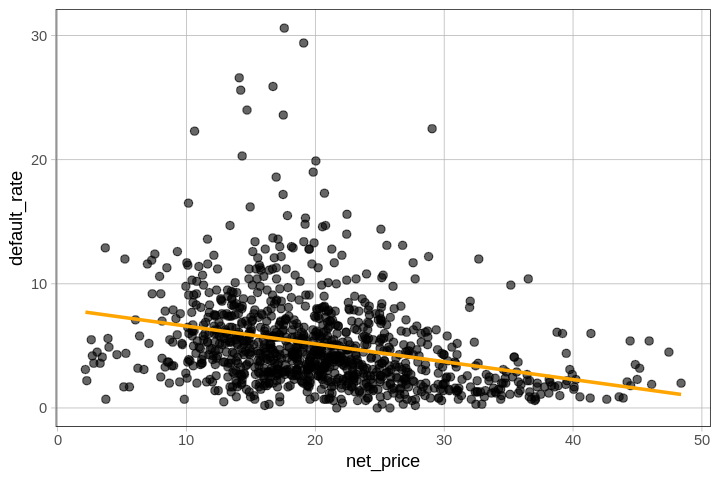

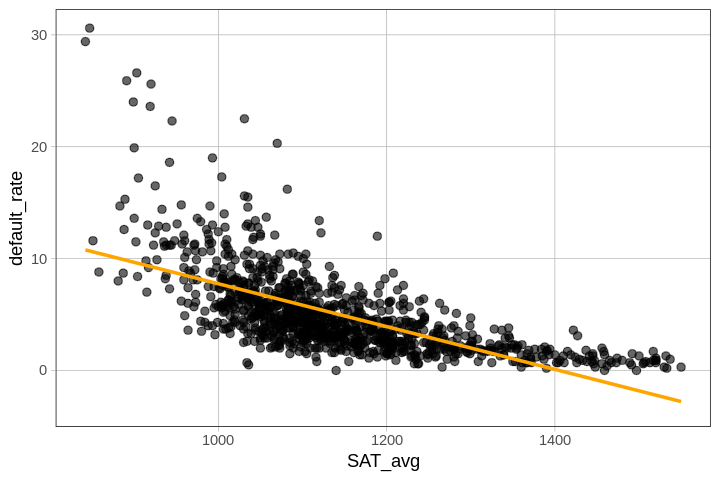

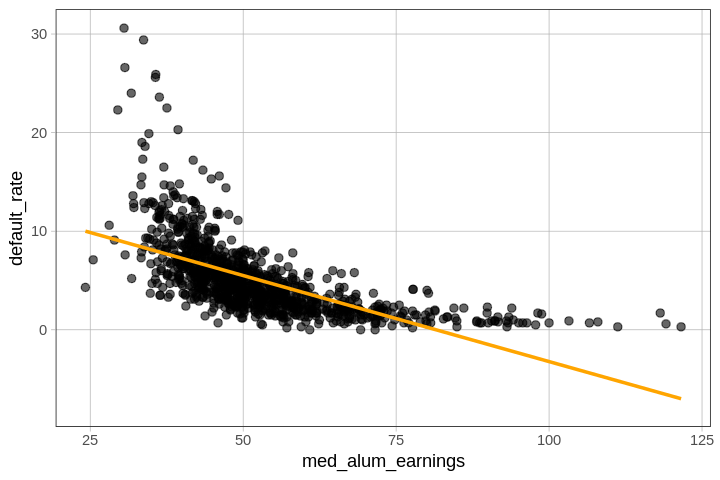

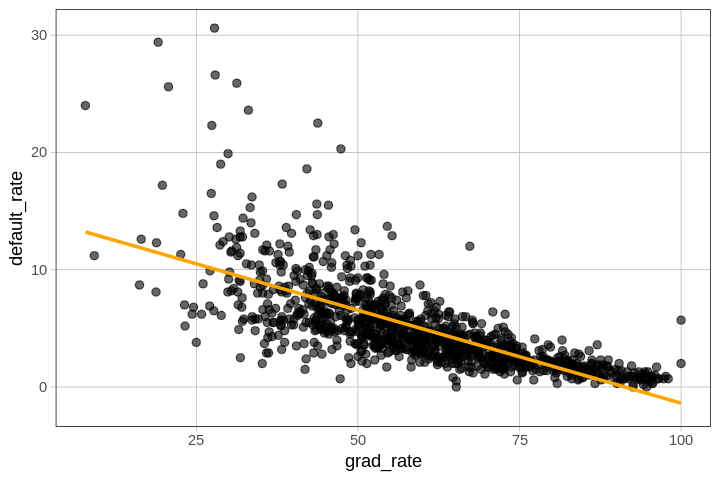

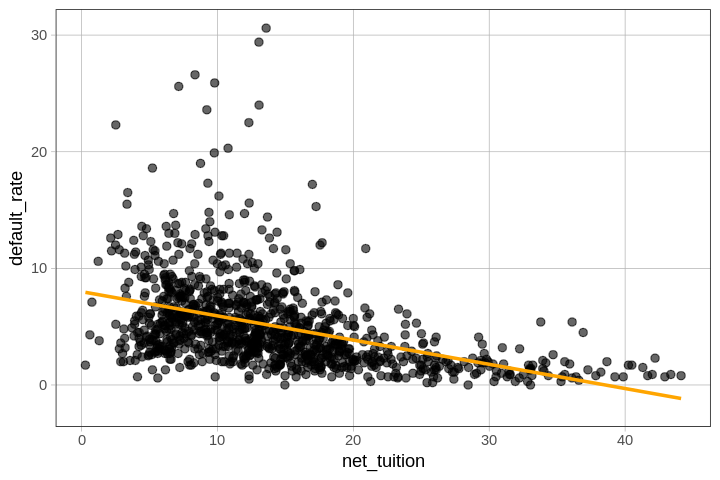

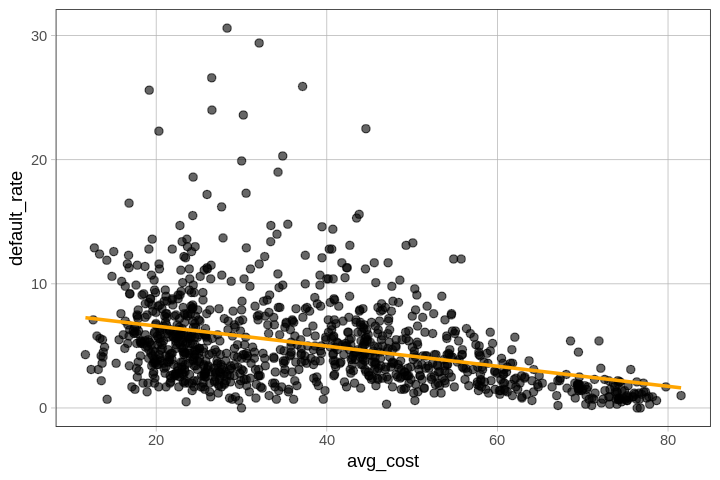

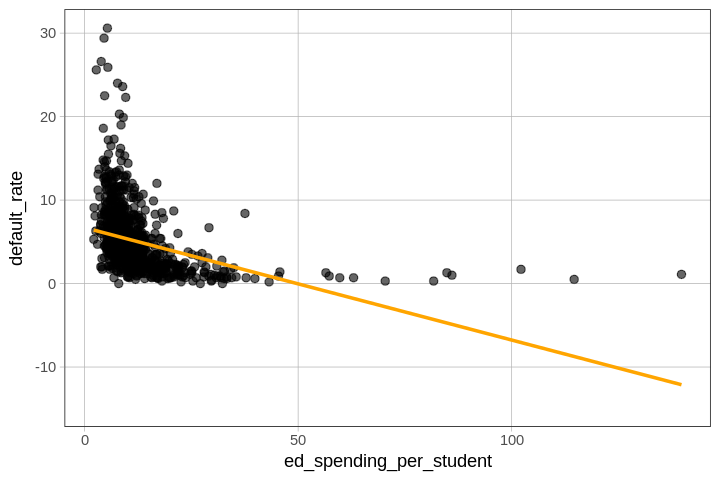

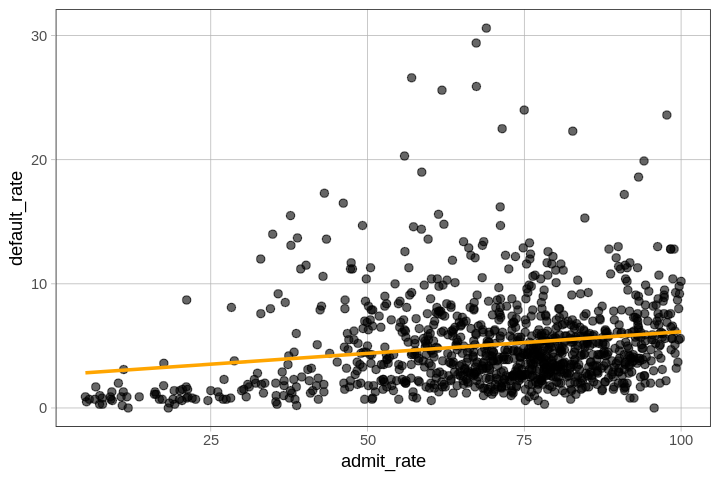

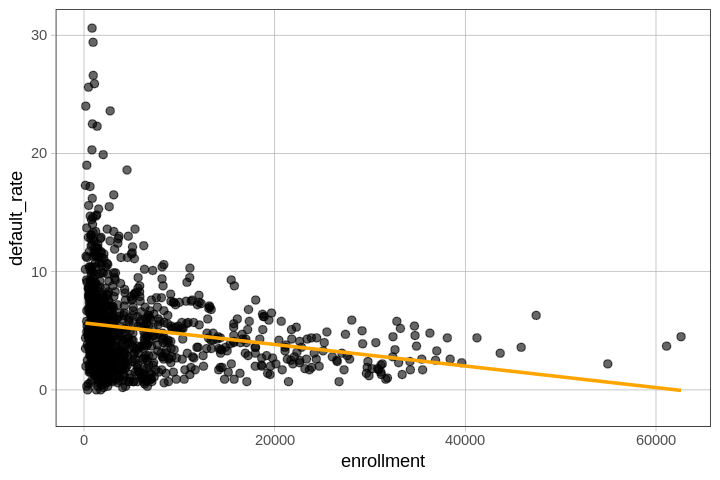

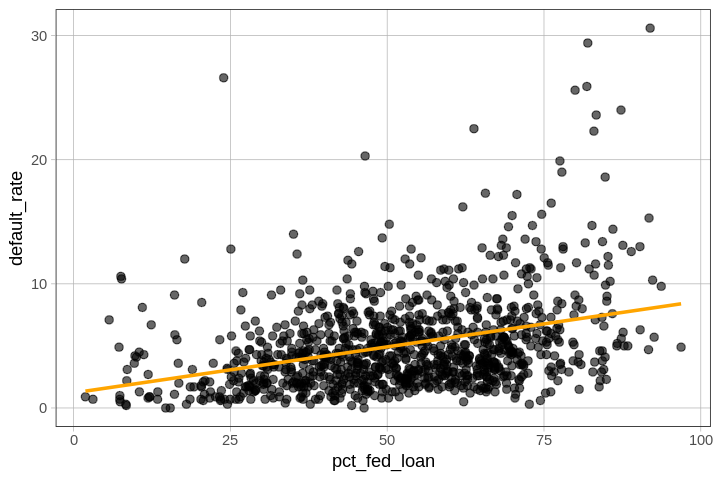

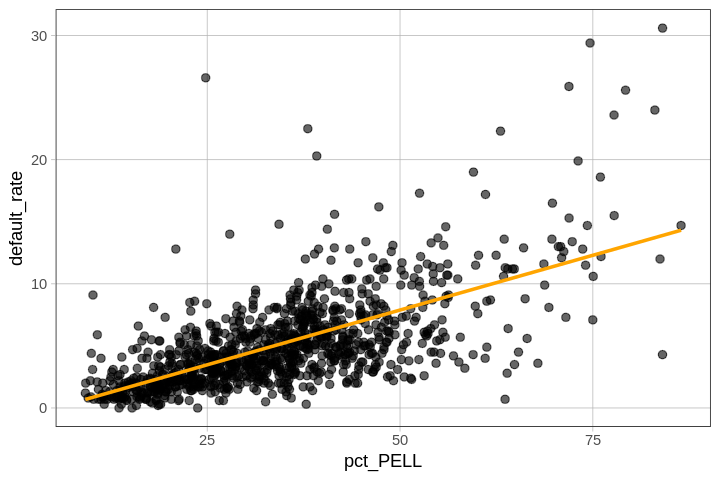

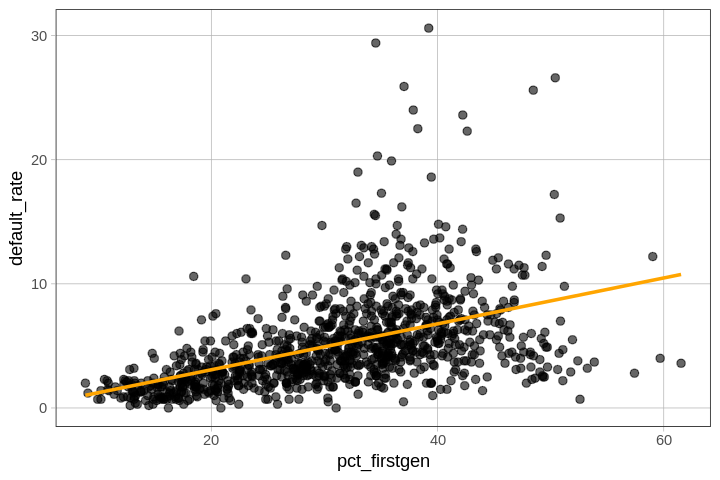

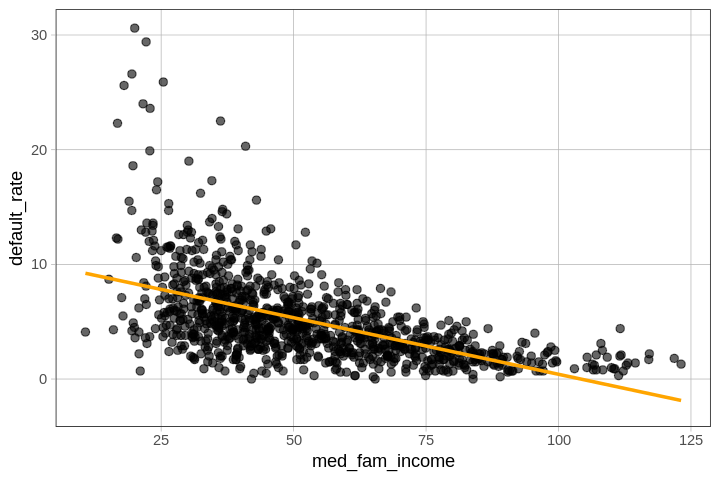

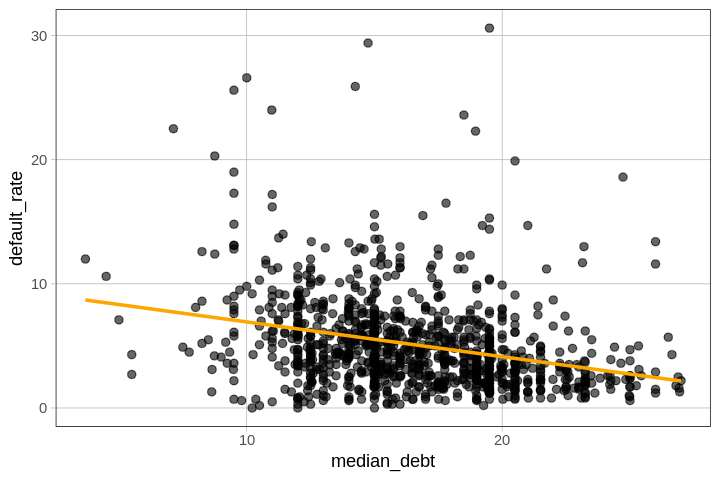

In [ ]:
gf_point(data=dat, default_rate ~ net_price) %>% gf_lm(color="orange")
gf_point(data=dat, default_rate ~ SAT_avg) %>% gf_lm(color="orange")
gf_point(data=dat, default_rate ~ med_alum_earnings) %>% gf_lm(color="orange")
gf_point(data=dat, default_rate ~ grad_rate) %>% gf_lm(color="orange")
gf_point(data=dat, default_rate ~ net_tuition) %>% gf_lm(color="orange")
gf_point(data=dat, default_rate ~ avg_cost) %>% gf_lm(color="orange")
gf_point(data=dat, default_rate ~ ed_spending_per_student) %>% gf_lm(color="orange")
gf_point(data=dat, default_rate ~ admit_rate) %>% gf_lm(color="orange")
gf_point(data=dat, default_rate ~ enrollment) %>% gf_lm(color="orange")
gf_point(data=dat, default_rate ~ pct_fed_loan) %>% gf_lm(color="orange")
gf_point(data=dat, default_rate ~ pct_PELL) %>% gf_lm(color="orange")
gf_point(data=dat, default_rate ~ pct_firstgen) %>% gf_lm(color="orange")
gf_point(data=dat, default_rate ~ med_fam_income) %>% gf_lm(color="orange")
gf_point(data=dat, default_rate ~ median_debt) %>% gf_lm(color="orange")

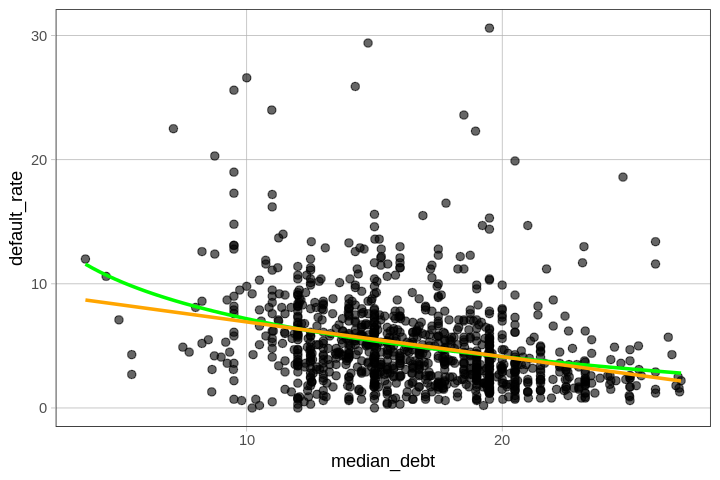

In [ ]:
# checking if log fits better
gf_point(data = dat, default_rate ~ median_debt) %>%
  gf_lm(formula = y ~ I(log(x)), color = "green") %>%
  gf_lm(formula = y ~ poly(x, 1), color = "orange")

# Testing max degrees

In [ ]:
# testing optimal poly degree for each predictor
# best Rsquared from degrees 1:max_possible_degree_for_each_predictor

build_and_evaluate_model <- function(var_name, max_degree) {
  best_poly   <- 0
  best_rsq    <- 0

  for (i in 1:max_degree) {

    formula_text <- paste0(
      "default_rate ~ poly(", var_name, ", ", i, ")"
    )

    my_model <- lm(as.formula(formula_text), data = train)
    preds    <- predict(my_model, newdata = test)
    rsq      <- cor(test$default_rate, preds)^2

    if (rsq > best_rsq) {
      best_rsq  <- rsq
      best_poly <- i
    }
  }

  cat(var_name,
      "    best degree:", best_poly,
      "    best Rsquared:", round(best_rsq, 4), "\n")

  invisible(list(var = var_name, degree = best_poly, R2 = best_rsq))
}


max_degrees <- list(
  SAT_avg           = 23,
  enrollment        = 15,
  net_price         = 23,
  avg_cost          = 23,
  net_tuition       = 20,
  avg_faculty_salary= 19,
  pct_PELL          = 21,
  pct_fed_loan      = 25,
  grad_rate         = 24,
  med_fam_income    = 21,
  med_alum_earnings = 19,
  pct_firstgen      = 23
)

# loop to test best degrees

for (var in names(max_degrees)) {
  build_and_evaluate_model(var, max_degrees[[var]])
}

SAT_avg     best degree: 14     best Rsquared: 0.4828 
enrollment     best degree: 7     best Rsquared: 0.0657 
net_price     best degree: 3     best Rsquared: 0.113 
avg_cost     best degree: 19     best Rsquared: 0.2134 
net_tuition     best degree: 18     best Rsquared: 0.2626 
avg_faculty_salary     best degree: 6     best Rsquared: 0.2719 
pct_PELL     best degree: 1     best Rsquared: 0.4362 
pct_fed_loan     best degree: 1     best Rsquared: 0.1192 
grad_rate     best degree: 2     best Rsquared: 0.5561 
med_fam_income     best degree: 1     best Rsquared: 0.3403 
med_alum_earnings     best degree: 9     best Rsquared: 0.5191 
pct_firstgen     best degree: 7     best Rsquared: 0.3228 


In [ ]:
# veirfying base model
my_model <- lm(data = train, default_rate ~ poly(grad_rate, 2) + poly(avg_faculty_salary, 6) + poly(med_alum_earnings, 9) + poly(pct_firstgen, 7) + med_fam_income + poly(SAT_avg, 14) + poly(avg_cost, 19) + log(enrollment) +
  avg_cost:net_price + grad_rate:med_alum_earnings + poly(admit_rate,1) + pct_PELL + pct_fed_loan + net_tuition + poly(enrollment, 7))

preds <- predict(my_model, newdata = test)

cor(test$default_rate, preds)^2


[1] 0.6888847

# 2-way interactions

In [ ]:
# adding interaction terms

dat$name   <- NULL
dat$city   <- NULL
dat$state  <- NULL
dat$region <- NULL

base_terms <- c(
  "poly(grad_rate, 2)",
  "poly(avg_faculty_salary, 6)",
  "poly(med_alum_earnings, 9)",
  "poly(pct_firstgen, 7)",
  "med_fam_income",
  "poly(SAT_avg, 14)",
  "poly(avg_cost, 19)",
  "log(enrollment)",
  "avg_cost:net_price",
  "grad_rate:med_alum_earnings",
  "admit_rate",
  "pct_PELL",
  "pct_fed_loan",
  "net_tuition",
  "poly(enrollment, 7)"
)

# helper funcs

get_r2 <- function(model, test_data) {
  preds <- predict(model, newdata = test_data)
  cor(test_data$default_rate, preds)^2
}

is_in_terms <- function(term, term_list) {
  parts <- strsplit(term, ":")[[1]] # [[1]] turns the list into a vector
  rev_term <- paste(rev(parts), collapse = ":")
  term %in% term_list || rev_term %in% term_list # avoidin redundant additions to base terms
}

round_num <- 1
improvement <- TRUE
best_r2 <- -Inf

while (improvement) {
  cat("\n========== ROUND", round_num, "==========\n")

  formula_str <- paste("default_rate ~", paste(base_terms, collapse = " + "))
  base_model <- lm(as.formula(formula_str), data = train)
  current_r2 <- get_r2(base_model, test)

  all_vars <- setdiff(names(dat), "default_rate")
  interactions <- combn(all_vars, 2, FUN = function(x) paste(x, collapse = ":"), simplify = TRUE)

  # ensure no redundancy in base terms
  new_candidates <- interactions[!vapply(interactions, function(x) is_in_terms(x, base_terms), logical(1))]

  best_add <- NULL
  best_add_r2 <- current_r2

  for (int_term in new_candidates) {
    temp_formula <- paste("default_rate ~", paste(c(base_terms, int_term), collapse = " + "))
    mod <- lm(as.formula(temp_formula), data = train)
    temp_r2 <- get_r2(mod, test)

    if (temp_r2 > best_add_r2) {
      best_add <- int_term
      best_add_r2 <- temp_r2
    }
  }

  # Check if improvement occurred
  if (!is.null(best_add)) {
    base_terms <- c(base_terms, best_add)
    best_r2 <- best_add_r2
    cat("Added interaction:", best_add, "-> Rsquared =", round(best_add_r2, 4), "\n")
    round_num <- round_num + 1
  } else {
    cat("No interactions improved Rsquared (current =", round(current_r2, 4), "). Stopping.\n")
    improvement <- FALSE
  }
}

# final output
cat("\nFinal Rsquared:", round(best_r2, 4), "\n")
cat("Final model has", length(base_terms), "terms.\n")
cat("\nFinal formula:\nmy_model <- lm(data = train,\n  default_rate ~ \n    ",
    paste(base_terms, collapse = " +\n    "), ")\n", sep = "")



========== ROUND 1 ==========


Warning message in predict.lm(model, newdata = test_data):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(model, newdata = test_data):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”


Added interaction: enrollment:pct_PELL -> Rsquared = 0.6947 

========== ROUND 2 ==========


Warning message in predict.lm(model, newdata = test_data):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(model, newdata = test_data):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”


Added interaction: highest_degree:net_price -> Rsquared = 0.7013 

========== ROUND 3 ==========


...

Added interaction: enrollment:pct_firstgen -> Rsquared = 0.7669 

========== ROUND 45 ==========


Warning message in predict.lm(model, newdata = test_data):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(model, newdata = test_data):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”


Added interaction: highest_degree:net_tuition -> Rsquared = 0.767 

========== ROUND 46 ==========


Warning message in predict.lm(model, newdata = test_data):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(model, newdata = test_data):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”


No interactions improved Rsquared (current = 0.767 ). Stopping.

Final Rsquared: 0.767 
Final model has 60 terms.

Final formula:
my_model <- lm(data = train,
  default_rate ~ 
    poly(grad_rate, 2) +
    poly(avg_faculty_salary, 6) +
    poly(med_alum_earnings, 9) +
    poly(pct_firstgen, 7) +
    med_fam_income +
    poly(SAT_avg, 14) +
    poly(avg_cost, 19) +
    log(enrollment) +
    avg_cost:net_price +
    grad_rate:med_alum_earnings +
    admit_rate +
    pct_PELL +
    pct_fed_loan +
    net_tuition +
    poly(enrollment, 7) +
    enrollment:pct_PELL +
    highest_degree:net_price +
    median_debt:highest_degree +
    avg_cost:pct_fed_loan +
    median_debt:avg_faculty_salary +
    net_tuition:grad_rate +
    enrollment:med_alum_earnings +
    net_price:grad_rate +
    enrollment:avg_faculty_salary +
    median_debt:admit_rate +
    admit_rate:pct_firstgen +
    pct_PELL:med_fam_income +
    highest_degree:admit_rate +
    highest_degree:med_fam_income +
    pct_PELL:med_alu

# Trimming

In [ ]:
# trimming model to prevent overfitting

full_formula <- "default_rate ~ poly(grad_rate, 2) + poly(avg_faculty_salary, 6) + log(med_alum_earnings) + poly(pct_firstgen, 7) +
    poly(SAT_avg, 14) + poly(avg_cost, 19) + log(enrollment) + poly(enrollment, 2) + log(ed_spending_per_student) + log(median_debt) + avg_cost:net_price + grad_rate:med_alum_earnings + poly(admit_rate, 1) + highest_degree:net_tuition + admit_rate:pct_fed_loan +
    median_debt:pct_firstgen + highest_degree:net_price + avg_cost:pct_fed_loan + admit_rate:med_fam_income + admit_rate:pct_firstgen +
    median_debt:highest_degree + avg_faculty_salary:med_alum_earnings + pct_fed_loan:pct_firstgen + pct_firstgen:med_fam_income + median_debt:med_alum_earnings + net_price:grad_rate + SAT_avg:net_price + median_debt:avg_cost + med_fam_income:med_alum_earnings +
    admit_rate:ed_spending_per_student + median_debt:enrollment + enrollment:med_fam_income + SAT_avg:med_alum_earnings + median_debt:SAT_avg +
    admit_rate:grad_rate + pct_PELL:med_alum_earnings + avg_faculty_salary:grad_rate + hbcu:enrollment + admit_rate:net_price + ed_spending_per_student:med_fam_income + net_price:ed_spending_per_student + net_price:pct_firstgen +
    net_price:pct_fed_loan + highest_degree:hbcu + SAT_avg:ed_spending_per_student + ed_spending_per_student:grad_rate + median_debt:avg_faculty_salary + net_tuition:med_fam_income + ed_spending_per_student:pct_PELL +
    OPEID:enrollment + ed_spending_per_student:med_alum_earnings + enrollment:net_price + highest_degree:ed_spending_per_student + OPEID:grad_rate + avg_cost:avg_faculty_salary + ownership:net_tuition + ownership:med_fam_income +
    admit_rate:net_tuition + avg_cost:pct_firstgen"

full_model <- lm(as.formula(full_formula), data = train)
full_preds <- predict(full_model, newdata = test)
baseline_r2 <- round(cor(test$default_rate, full_preds)^2, 4)
cat("Baseline Rsquared:", baseline_r2, "\n\n")

terms_str <- strsplit(full_formula, "~")[[1]][2]
predictors <- trimws(unlist(strsplit(terms_str, "\\+")))

results <- data.frame(removed = character(), r2 = numeric(), stringsAsFactors = FALSE)

for (pred in predictors) {
  reduced_preds <- setdiff(predictors, pred)
  reduced_formula <- paste("default_rate ~", paste(reduced_preds, collapse = " + "))
  model <- lm(as.formula(reduced_formula), data = train)
  preds <- predict(model, newdata = test)
  r2 <- round(cor(test$default_rate, preds)^2, 4)
  results <- rbind(results, data.frame(removed = pred, r2 = r2))
  cat("Removed:", pred, "-> Rsquared:", r2, "\n")
}

better <- subset(results, r2 > baseline_r2)

cat("\n---\nPredictors whose removal improved test Rsquared:\n")
print(better[order(-better$r2), ])


Baseline Rsquared: 0.7766 

Removed: poly(grad_rate, 2) -> Rsquared: 0.7707 
Removed: poly(avg_faculty_salary, 6) -> Rsquared: 0.7688 
Removed: log(med_alum_earnings) -> Rsquared: 0.7623 
Removed: poly(pct_firstgen, 7) -> Rsquared: 0.7594 
Removed: poly(SAT_avg, 14) -> Rsquared: 0.7318 
Removed: poly(avg_cost, 19) -> Rsquared: 0.7427 
Removed: log(enrollment) -> Rsquared: 0.7763 
Removed: poly(enrollment, 2) -> Rsquared: 0.774 
Removed: log(ed_spending_per_student) -> Rsquared: 0.7767 
Removed: log(median_debt) -> Rsquared: 0.7701 
Removed: avg_cost:net_price -> Rsquared: 0.7689 
Removed: grad_rate:med_alum_earnings -> Rsquared: 0.7752 
Removed: poly(admit_rate, 1) -> Rsquared: 0.77 
Removed: highest_degree:net_tuition -> Rsquared: 0.7755 
Removed: admit_rate:pct_fed_loan -> Rsquared: 0.7766 
Removed: median_debt:pct_firstgen -> Rsquared: 0.7428 
Removed: highest_degree:net_price -> Rsquared: 0.7663 
Removed: avg_cost:pct_fed_loan -> Rsquared: 0.7765 
Removed: admit_rate:med_fam_income

In [ ]:
# verifying model
# adding log(median_debt)

my_model <- lm(default_rate ~
    poly(grad_rate, 2) +
    poly(avg_faculty_salary, 6) +
    log(med_alum_earnings) +
    poly(pct_firstgen, 7) +
    med_fam_income +
    poly(SAT_avg, 14) +
    poly(avg_cost, 19) +
    log(enrollment) +
    avg_cost:net_price +
    admit_rate +
    pct_PELL +
    pct_fed_loan +
    net_tuition +
    poly(enrollment, 7) +
    enrollment:pct_PELL +
    highest_degree:net_price +
    median_debt:highest_degree +
    avg_cost:pct_fed_loan +
    median_debt:avg_faculty_salary +
    enrollment:med_alum_earnings +
    net_price:grad_rate +
    enrollment:avg_faculty_salary +
    median_debt:admit_rate +
    admit_rate:pct_firstgen +
    pct_PELL:med_fam_income +
    highest_degree:admit_rate +
    highest_degree:med_fam_income +
    pct_PELL:med_alum_earnings +
    SAT_avg:net_price +
    admit_rate:enrollment +
    admit_rate:pct_fed_loan +
    SAT_avg:med_fam_income +
    median_debt:net_tuition +
    median_debt:grad_rate +
    net_price:pct_fed_loan +
    net_tuition:med_fam_income +
    net_price:med_fam_income +
    median_debt:med_alum_earnings +
    avg_cost:med_fam_income +
    avg_faculty_salary:grad_rate +
    pct_firstgen:med_fam_income +
    pct_fed_loan:med_alum_earnings +
    net_tuition:avg_faculty_salary +
    hbcu:enrollment +
    highest_degree:grad_rate +
    highest_degree:avg_faculty_salary +
    highest_degree:hbcu +
    SAT_avg:med_alum_earnings +
    avg_cost:med_alum_earnings +
    median_debt:enrollment +
    enrollment:pct_fed_loan +
    median_debt:avg_cost +
    admit_rate:grad_rate +
    admit_rate:net_tuition +
    pct_PELL:pct_firstgen +
    SAT_avg:pct_PELL +
    enrollment:pct_firstgen +
    highest_degree:net_tuition,

  data = train)

preds <- predict(my_model, newdata = test)

round(cor(test$default_rate, preds)^2, 4)

[1] 0.7701

In [ ]:
# manual tweaking and comparing

my_model <- lm(default_rate ~ poly(grad_rate, 2) + poly(avg_faculty_salary, 6) + sqrt(med_alum_earnings) + poly(pct_firstgen, 7) +
    poly(SAT_avg, 14) + poly(avg_cost, 19) + log(enrollment) + poly(enrollment, 2) + log(ed_spending_per_student) + log(median_debt) + avg_cost:net_price + grad_rate:med_alum_earnings + poly(admit_rate, 1) + highest_degree:net_tuition + admit_rate:pct_fed_loan +
    median_debt:pct_firstgen + highest_degree:net_price + avg_cost:pct_fed_loan + admit_rate:med_fam_income + admit_rate:pct_firstgen +
    median_debt:highest_degree + avg_faculty_salary:med_alum_earnings + pct_fed_loan:pct_firstgen + pct_firstgen:med_fam_income + median_debt:med_alum_earnings + net_price:grad_rate + SAT_avg:net_price + median_debt:avg_cost +
    admit_rate:ed_spending_per_student + enrollment:med_fam_income + SAT_avg:med_alum_earnings + median_debt:SAT_avg +
    admit_rate:grad_rate + pct_PELL:med_alum_earnings + avg_faculty_salary:grad_rate + hbcu:enrollment + admit_rate:net_price + net_price:ed_spending_per_student + net_price:pct_firstgen +
    net_price:pct_fed_loan + highest_degree:hbcu + SAT_avg:ed_spending_per_student + ed_spending_per_student:grad_rate + median_debt:avg_faculty_salary + net_tuition:med_fam_income + ed_spending_per_student:pct_PELL +
    OPEID:enrollment + ed_spending_per_student:med_alum_earnings + enrollment:net_price + highest_degree:ed_spending_per_student + OPEID:grad_rate + avg_cost:avg_faculty_salary + ownership:net_tuition + ownership:med_fam_income +
    admit_rate:net_tuition + avg_cost:pct_firstgen + sqrt(med_alum_earnings)
  , data = train)

preds <- predict(my_model, newdata = test)

round(cor(test$default_rate, preds) ^ 2, 4)

[1] 0.7806

# 3-way interactions

In [ ]:
# testing 3-way interactions


base_formula <- default_rate ~
  poly(grad_rate, 2) +
  poly(avg_faculty_salary, 6) +
  sqrt(med_alum_earnings) +
  poly(pct_firstgen, 7) +
  poly(SAT_avg, 14) +
  poly(avg_cost, 19) +
  log(enrollment) +
  poly(enrollment, 2) +
  log(ed_spending_per_student) +
  log(median_debt) +
  avg_cost:net_price +
  grad_rate:med_alum_earnings +
  poly(admit_rate, 1) +
  highest_degree:net_tuition +
  admit_rate:pct_fed_loan +
  median_debt:pct_firstgen +
  highest_degree:net_price +
  avg_cost:pct_fed_loan +
  admit_rate:med_fam_income +
  admit_rate:pct_firstgen +
  median_debt:highest_degree +
  avg_faculty_salary:med_alum_earnings +
  pct_fed_loan:pct_firstgen +
  pct_firstgen:med_fam_income +
  median_debt:med_alum_earnings +
  net_price:grad_rate +
  SAT_avg:net_price +
  median_debt:avg_cost +
  admit_rate:ed_spending_per_student +
  enrollment:med_fam_income +
  SAT_avg:med_alum_earnings +
  median_debt:SAT_avg +
  admit_rate:grad_rate +
  pct_PELL:med_alum_earnings +
  avg_faculty_salary:grad_rate +
  hbcu:enrollment +
  admit_rate:net_price +
  net_price:ed_spending_per_student +
  net_price:pct_firstgen +
  net_price:pct_fed_loan +
  highest_degree:hbcu +
  SAT_avg:ed_spending_per_student +
  ed_spending_per_student:grad_rate +
  median_debt:avg_faculty_salary +
  net_tuition:med_fam_income +
  ed_spending_per_student:pct_PELL +
  OPEID:enrollment +
  ed_spending_per_student:med_alum_earnings +
  enrollment:net_price +
  highest_degree:ed_spending_per_student +
  OPEID:grad_rate +
  avg_cost:avg_faculty_salary +
  ownership:net_tuition +
  ownership:med_fam_income +
  admit_rate:net_tuition +
  avg_cost:pct_firstgen +
  sqrt(med_alum_earnings)

# base model r^2
base_model <- lm(base_formula, data = train)
base_preds <- predict(base_model, newdata = test)
base_r2    <- cor(test$default_rate, base_preds)^2
cat("Baseline Rsquared:", round(base_r2, 4), "\n\n")

all_vars       <- all.vars(base_formula)
unique_preds   <- setdiff(all_vars, "default_rate")

# all 3 way combinations
triplets <- combn(unique_preds, 3, simplify = FALSE)

accepted_interactions <- character(0)
current_r2            <- base_r2
current_formula       <- base_formula


try_add_interaction <- function(formula_so_far, interaction_term) {
  candidate_formula <- update(formula_so_far, paste(". ~ . +", interaction_term))

  result <- tryCatch({
    m      <- lm(candidate_formula, data = train)
    preds  <- predict(m, newdata = test)
    new_r2 <- cor(test$default_rate, preds)^2

    # Only return new_r2 if it is not NA / not error
    if (!is.na(new_r2)) return(new_r2)
    else                    return(NA)
  },
  error   = function(e) { return(NA) },
  warning = function(w) { return(NA) }
  )

  return(result)
}

cat("Searching for 3‐way interactions that boost R²...\n\n")

for (trip in triplets) {
  # string "var1:var2:var3"
  inter_str <- paste(trip, collapse = ":")

  new_r2 <- try_add_interaction(current_formula, inter_str)

  if (!is.na(new_r2) && new_r2 > current_r2) {
    cat(
      "adding ", inter_str,
      "improved Rsquared from", round(current_r2, 4),
      "->", round(new_r2, 4), "\n"
    )
    # permanently add  interaction
    accepted_interactions <- c(accepted_interactions, inter_str)
    current_r2            <- new_r2
    current_formula       <- update(current_formula, paste(". ~ . +", inter_str))
  }
}

cat("\n---\nAccepted 3‐way interactions:\n")
if (length(accepted_interactions) == 0) {
  cat("  (none improved Rsquared)\n")
} else {
  for (term in accepted_interactions) {
    cat(term, "\n")
  }
}


Baseline R²: 0.7806 

Searching for 3‐way interactions that boost R²...

adding  grad_rate:avg_faculty_salary:SAT_avg improved Rsquared from 0.7806 -> 0.7806 
adding  grad_rate:avg_faculty_salary:admit_rate improved Rsquared from 0.7806 -> 0.7806 
adding  grad_rate:med_alum_earnings:enrollment improved Rsquared from 0.7806 -> 0.781 
adding  grad_rate:med_alum_earnings:median_debt improved Rsquared from 0.781 -> 0.7811 
adding  grad_rate:med_alum_earnings:ownership improved Rsquared from 0.7811 -> 0.7813 
adding  grad_rate:pct_firstgen:SAT_avg improved Rsquared from 0.7813 -> 0.7813 
adding  grad_rate:SAT_avg:enrollment improved Rsquared from 0.7813 -> 0.7822 
adding  grad_rate:SAT_avg:net_tuition improved Rsquared from 0.7822 -> 0.7823 
adding  grad_rate:avg_cost:enrollment improved Rsquared from 0.7823 -> 0.7829 
adding  grad_rate:enrollment:ed_spending_per_student improved Rsquared from 0.7829 -> 0.7829 
adding  grad_rate:enrollment:median_debt improved Rsquared from 0.7829 -> 0.7844

In [ ]:
# verifying model

my_model <- lm(default_rate ~
    poly(grad_rate, 2) +
    poly(avg_faculty_salary, 6) +
    sqrt(med_alum_earnings) +
    poly(pct_firstgen, 7) +
    poly(SAT_avg, 14) +
    poly(avg_cost, 19) +
    log(enrollment) +
    poly(enrollment, 2) +
    log(ed_spending_per_student) +
    log(median_debt) +
    avg_cost:net_price +
    grad_rate:med_alum_earnings +
    poly(admit_rate, 1) +
    highest_degree:net_tuition +
    admit_rate:pct_fed_loan +
    median_debt:pct_firstgen +
    highest_degree:net_price +
    avg_cost:pct_fed_loan +
    admit_rate:med_fam_income +
    admit_rate:pct_firstgen +
    median_debt:highest_degree +
    avg_faculty_salary:med_alum_earnings +
    pct_fed_loan:pct_firstgen +
    pct_firstgen:med_fam_income +
    median_debt:med_alum_earnings +
    net_price:grad_rate +
    SAT_avg:net_price +
    median_debt:avg_cost +
    admit_rate:ed_spending_per_student +
    enrollment:med_fam_income +
    SAT_avg:med_alum_earnings +
    median_debt:SAT_avg +
    admit_rate:grad_rate +
    pct_PELL:med_alum_earnings +
    avg_faculty_salary:grad_rate +
    hbcu:enrollment +
    admit_rate:net_price +
    net_price:ed_spending_per_student +
    net_price:pct_firstgen +
    net_price:pct_fed_loan +
    highest_degree:hbcu +
    SAT_avg:ed_spending_per_student +
    ed_spending_per_student:grad_rate +
    median_debt:avg_faculty_salary +
    net_tuition:med_fam_income +
    ed_spending_per_student:pct_PELL +
    OPEID:enrollment +
    ed_spending_per_student:med_alum_earnings +
    enrollment:net_price +
    highest_degree:ed_spending_per_student +
    OPEID:grad_rate +
    avg_cost:avg_faculty_salary +
    ownership:net_tuition +
    ownership:med_fam_income +
    admit_rate:net_tuition +
    avg_cost:pct_firstgen +
    sqrt(med_alum_earnings) +
    grad_rate:avg_faculty_salary:SAT_avg +
    grad_rate:avg_faculty_salary:admit_rate +
    grad_rate:med_alum_earnings:enrollment +
    grad_rate:med_alum_earnings:median_debt +
    grad_rate:med_alum_earnings:ownership +
    grad_rate:pct_firstgen:SAT_avg +
    grad_rate:SAT_avg:enrollment +
    grad_rate:SAT_avg:net_tuition +
    grad_rate:avg_cost:enrollment +
    grad_rate:enrollment:ed_spending_per_student +
    grad_rate:enrollment:median_debt +
    grad_rate:enrollment:net_tuition +
    grad_rate:ed_spending_per_student:net_tuition +
    grad_rate:median_debt:OPEID +
    grad_rate:net_price:med_fam_income +
    grad_rate:admit_rate:pct_PELL +
    grad_rate:net_tuition:med_fam_income +
    grad_rate:med_fam_income:OPEID +
    avg_faculty_salary:med_alum_earnings:enrollment +
    avg_faculty_salary:med_alum_earnings:ed_spending_per_student +
    avg_faculty_salary:med_alum_earnings:net_price +
    avg_faculty_salary:pct_firstgen:enrollment +
    avg_faculty_salary:pct_firstgen:med_fam_income +
    avg_faculty_salary:SAT_avg:avg_cost +
    avg_faculty_salary:SAT_avg:enrollment +
    avg_faculty_salary:SAT_avg:admit_rate +
    avg_faculty_salary:SAT_avg:highest_degree +
    avg_faculty_salary:SAT_avg:pct_PELL +
    avg_faculty_salary:avg_cost:net_tuition +
    avg_faculty_salary:avg_cost:med_fam_income +
    avg_faculty_salary:enrollment:admit_rate +
    avg_faculty_salary:median_debt:net_tuition +
    avg_faculty_salary:median_debt:pct_fed_loan +
    avg_faculty_salary:net_price:pct_fed_loan +
    avg_faculty_salary:admit_rate:net_tuition +
    avg_faculty_salary:net_tuition:pct_PELL +
    med_alum_earnings:pct_firstgen:enrollment +
    med_alum_earnings:pct_firstgen:net_price +
    med_alum_earnings:SAT_avg:highest_degree +
    med_alum_earnings:SAT_avg:med_fam_income +
    med_alum_earnings:enrollment:net_price +
    med_alum_earnings:enrollment:hbcu +
    med_alum_earnings:ed_spending_per_student:net_price +
    med_alum_earnings:ed_spending_per_student:OPEID +
    med_alum_earnings:net_price:med_fam_income +
    med_alum_earnings:admit_rate:med_fam_income +
    pct_firstgen:enrollment:admit_rate +
    pct_firstgen:enrollment:OPEID +
    pct_firstgen:ed_spending_per_student:admit_rate +
    pct_firstgen:net_price:admit_rate +
    pct_firstgen:net_price:net_tuition +
    pct_firstgen:net_price:med_fam_income +
    pct_firstgen:admit_rate:net_tuition +
    SAT_avg:enrollment:net_price +
    SAT_avg:enrollment:OPEID +
    SAT_avg:net_tuition:med_fam_income +
    avg_cost:enrollment:pct_fed_loan +
    avg_cost:median_debt:net_tuition +
    avg_cost:net_tuition:pct_PELL +
    enrollment:ed_spending_per_student:admit_rate +
    enrollment:ed_spending_per_student:pct_fed_loan +
    enrollment:ed_spending_per_student:pct_PELL +
    enrollment:ed_spending_per_student:hbcu +
    enrollment:net_price:pct_PELL +
    enrollment:net_tuition:pct_PELL +
    enrollment:med_fam_income:OPEID +
    enrollment:hbcu:OPEID +
    ed_spending_per_student:admit_rate:highest_degree +
    ed_spending_per_student:admit_rate:pct_PELL +
    ed_spending_per_student:highest_degree:hbcu +
    ed_spending_per_student:net_tuition:med_fam_income +
    median_debt:net_tuition:pct_fed_loan +
    net_price:net_tuition:pct_fed_loan
  , data = train)

preds <- predict(my_model, newdata = test)
round(cor(test$default_rate, preds)^2, 4)


[1] 0.8119

# Trimming

In [ ]:
# trimming model

base_formula <- default_rate ~
  poly(grad_rate, 2) +
  poly(avg_faculty_salary, 6) +
  sqrt(med_alum_earnings) +
  poly(pct_firstgen, 7) +
  poly(SAT_avg, 14) +
  poly(avg_cost, 19) +
  log(enrollment) +
  poly(enrollment, 2) +
  log(ed_spending_per_student) +
  log(median_debt) +
  avg_cost:net_price +
  grad_rate:med_alum_earnings +
  poly(admit_rate, 1) +
  highest_degree:net_tuition +
  admit_rate:pct_fed_loan +
  median_debt:pct_firstgen +
  highest_degree:net_price +
  avg_cost:pct_fed_loan +
  admit_rate:med_fam_income +
  admit_rate:pct_firstgen +
  median_debt:highest_degree +
  avg_faculty_salary:med_alum_earnings +
  pct_fed_loan:pct_firstgen +
  pct_firstgen:med_fam_income +
  median_debt:med_alum_earnings +
  net_price:grad_rate +
  SAT_avg:net_price +
  median_debt:avg_cost +
  admit_rate:ed_spending_per_student +
  enrollment:med_fam_income +
  SAT_avg:med_alum_earnings +
  median_debt:SAT_avg +
  admit_rate:grad_rate +
  pct_PELL:med_alum_earnings +
  avg_faculty_salary:grad_rate +
  hbcu:enrollment +
  admit_rate:net_price +
  net_price:ed_spending_per_student +
  net_price:pct_firstgen +
  net_price:pct_fed_loan +
  highest_degree:hbcu +
  SAT_avg:ed_spending_per_student +
  ed_spending_per_student:grad_rate +
  median_debt:avg_faculty_salary +
  net_tuition:med_fam_income +
  ed_spending_per_student:pct_PELL +
  OPEID:enrollment +
  ed_spending_per_student:med_alum_earnings +
  enrollment:net_price +
  highest_degree:ed_spending_per_student +
  OPEID:grad_rate +
  avg_cost:avg_faculty_salary +
  ownership:net_tuition +
  ownership:med_fam_income +
  admit_rate:net_tuition +
  avg_cost:pct_firstgen +
  sqrt(med_alum_earnings) +
  grad_rate:avg_faculty_salary:SAT_avg +
  grad_rate:avg_faculty_salary:admit_rate +
  grad_rate:med_alum_earnings:enrollment +
  grad_rate:med_alum_earnings:median_debt +
  grad_rate:med_alum_earnings:ownership +
  grad_rate:pct_firstgen:SAT_avg +
  grad_rate:SAT_avg:enrollment +
  grad_rate:SAT_avg:net_tuition +
  grad_rate:avg_cost:enrollment +
  grad_rate:enrollment:ed_spending_per_student +
  grad_rate:enrollment:median_debt +
  grad_rate:enrollment:net_tuition +
  grad_rate:ed_spending_per_student:net_tuition +
  grad_rate:median_debt:OPEID +
  grad_rate:net_price:med_fam_income +
  grad_rate:admit_rate:pct_PELL +
  grad_rate:net_tuition:med_fam_income +
  grad_rate:med_fam_income:OPEID +
  avg_faculty_salary:med_alum_earnings:enrollment +
  avg_faculty_salary:med_alum_earnings:ed_spending_per_student +
  avg_faculty_salary:med_alum_earnings:net_price +
  avg_faculty_salary:pct_firstgen:enrollment +
  avg_faculty_salary:pct_firstgen:med_fam_income +
  avg_faculty_salary:SAT_avg:avg_cost +
  avg_faculty_salary:SAT_avg:enrollment +
  avg_faculty_salary:SAT_avg:admit_rate +
  avg_faculty_salary:SAT_avg:highest_degree +
  avg_faculty_salary:SAT_avg:pct_PELL +
  avg_faculty_salary:avg_cost:net_tuition +
  avg_faculty_salary:avg_cost:med_fam_income +
  avg_faculty_salary:enrollment:admit_rate +
  avg_faculty_salary:median_debt:net_tuition +
  avg_faculty_salary:median_debt:pct_fed_loan +
  avg_faculty_salary:net_price:pct_fed_loan +
  avg_faculty_salary:admit_rate:net_tuition +
  avg_faculty_salary:net_tuition:pct_PELL +
  med_alum_earnings:pct_firstgen:enrollment +
  med_alum_earnings:pct_firstgen:net_price +
  med_alum_earnings:SAT_avg:highest_degree +
  med_alum_earnings:SAT_avg:med_fam_income +
  med_alum_earnings:enrollment:net_price +
  med_alum_earnings:enrollment:hbcu +
  med_alum_earnings:ed_spending_per_student:net_price +
  med_alum_earnings:ed_spending_per_student:OPEID +
  med_alum_earnings:net_price:med_fam_income +
  med_alum_earnings:admit_rate:med_fam_income +
  pct_firstgen:enrollment:admit_rate +
  pct_firstgen:enrollment:OPEID +
  pct_firstgen:ed_spending_per_student:admit_rate +
  pct_firstgen:net_price:admit_rate +
  pct_firstgen:net_price:net_tuition +
  pct_firstgen:net_price:med_fam_income +
  pct_firstgen:admit_rate:net_tuition +
  SAT_avg:enrollment:net_price +
  SAT_avg:enrollment:OPEID +
  SAT_avg:net_tuition:med_fam_income +
  avg_cost:enrollment:pct_fed_loan +
  avg_cost:median_debt:net_tuition +
  avg_cost:net_tuition:pct_PELL +
  enrollment:ed_spending_per_student:admit_rate +
  enrollment:ed_spending_per_student:pct_fed_loan +
  enrollment:ed_spending_per_student:pct_PELL +
  enrollment:ed_spending_per_student:hbcu +
  enrollment:net_price:pct_PELL +
  enrollment:net_tuition:pct_PELL +
  enrollment:med_fam_income:OPEID +
  enrollment:hbcu:OPEID +
  ed_spending_per_student:admit_rate:highest_degree +
  ed_spending_per_student:admit_rate:pct_PELL +
  ed_spending_per_student:highest_degree:hbcu +
  ed_spending_per_student:net_tuition:med_fam_income +
  median_debt:net_tuition:pct_fed_loan +
  net_price:net_tuition:pct_fed_loan

# initial Rsquared (0.8119)
full_model <- lm(base_formula, data = train)
full_preds <- predict(full_model, newdata = test)
current_r2 <- cor(test$default_rate, full_preds)^2
cat("Initial (full) Rsquared:", round(current_r2, 4), "\n\n")

current_terms <- attr(terms(base_formula), "term.labels")

evaluate_removal <- function(terms_vec, remove_term) {
  # Build new term list without 'remove_term'
  new_terms <- setdiff(terms_vec, remove_term)
  new_formula <- reformulate(new_terms, response = "default_rate")

  r2_val <- tryCatch({
    m     <- lm(new_formula, data = train)
    preds <- predict(m, newdata = test)
    r2    <- cor(test$default_rate, preds)^2
    return(r2)
  }, error = function(e) return(NA), warning = function(w) return(NA))

  return(r2_val)
}

# 6. Backward elimination loop
improvement <- TRUE

while (improvement) {
  improvement   <- FALSE
  best_r2       <- current_r2
  term_to_remove <- NULL

  for (t in current_terms) {
    r2_after_removal <- evaluate_removal(current_terms, t)

    if (!is.na(r2_after_removal) && r2_after_removal > best_r2) {
      best_r2        <- r2_after_removal
      term_to_remove <- t
      improvement    <- TRUE
      break
    }
  }

  if (improvement) {
    cat(
      "Removed term:", term_to_remove,
      "-> Rsquared improved from", round(current_r2, 4),
      "to", round(best_r2, 4), "\n"
    )
    current_terms <- setdiff(current_terms, term_to_remove)
    current_r2    <- best_r2
  }
}

final_formula <- reformulate(current_terms, response = "default_rate")
cat("\nFinal formula after backward elimination:\n")
print(final_formula)

final_model <- lm(final_formula, data = train)
final_preds <- predict(final_model, newdata = test)
final_r2    <- cor(test$default_rate, final_preds)^2
cat("\nFinal model test Rsquared:", round(final_r2, 4), "\n")


Initial (full) Rsquared: 0.8119 



In [ ]:
my_model <- lm(default_rate ~ poly(grad_rate, 2) + poly(avg_faculty_salary,
    6) + sqrt(med_alum_earnings) + poly(pct_firstgen, 7) + poly(SAT_avg,
    14) + poly(avg_cost, 19) + log(enrollment) + log(ed_spending_per_student) +
    log(median_debt) + poly(admit_rate, 1) + avg_cost:net_price +
    grad_rate:med_alum_earnings + highest_degree:net_tuition +
    admit_rate:pct_fed_loan + net_price:highest_degree + avg_cost:pct_fed_loan +
    admit_rate:pct_firstgen + med_alum_earnings:avg_faculty_salary +
    pct_firstgen:med_fam_income + med_alum_earnings:median_debt +
    net_price:grad_rate + net_price:SAT_avg + avg_cost:median_debt +
    median_debt:SAT_avg + grad_rate:admit_rate + med_alum_earnings:pct_PELL +
    grad_rate:avg_faculty_salary + enrollment:hbcu + net_price:ed_spending_per_student +
    net_price:pct_firstgen + net_price:pct_fed_loan + highest_degree:hbcu +
    grad_rate:ed_spending_per_student + median_debt:avg_faculty_salary +
    net_tuition:med_fam_income + ed_spending_per_student:pct_PELL +
    med_alum_earnings:ed_spending_per_student + avg_cost:avg_faculty_salary +
    net_tuition:ownership + med_fam_income:ownership + net_tuition:admit_rate +
    avg_cost:pct_firstgen + grad_rate:admit_rate:avg_faculty_salary +
    grad_rate:med_alum_earnings:enrollment + grad_rate:med_alum_earnings:median_debt +
    grad_rate:med_alum_earnings:ownership + grad_rate:pct_firstgen:SAT_avg +
    grad_rate:SAT_avg:enrollment + avg_cost:grad_rate:enrollment +
    grad_rate:ed_spending_per_student:enrollment + grad_rate:net_tuition:enrollment +
    grad_rate:net_tuition:ed_spending_per_student + grad_rate:median_debt:OPEID +
    grad_rate:admit_rate:pct_PELL + grad_rate:net_tuition:med_fam_income +
    grad_rate:med_fam_income:OPEID + med_alum_earnings:avg_faculty_salary:enrollment +
    med_alum_earnings:avg_faculty_salary:ed_spending_per_student +
    pct_firstgen:avg_faculty_salary:enrollment + pct_firstgen:med_fam_income:avg_faculty_salary +
    avg_cost:avg_faculty_salary:SAT_avg + avg_faculty_salary:SAT_avg:enrollment +
    admit_rate:avg_faculty_salary:enrollment + net_tuition:median_debt:avg_faculty_salary +
    net_tuition:admit_rate:avg_faculty_salary + net_tuition:avg_faculty_salary:pct_PELL +
    net_price:med_alum_earnings:pct_firstgen + med_alum_earnings:highest_degree:SAT_avg +
    net_price:med_alum_earnings:enrollment + med_alum_earnings:enrollment:hbcu +
    net_price:med_alum_earnings:ed_spending_per_student + net_price:med_alum_earnings:med_fam_income +
    admit_rate:pct_firstgen:enrollment + pct_firstgen:enrollment:OPEID +
    net_price:admit_rate:pct_firstgen + net_price:pct_firstgen:med_fam_income +
    net_tuition:admit_rate:pct_firstgen + net_price:SAT_avg:enrollment +
    net_tuition:med_fam_income:SAT_avg + avg_cost:net_tuition:median_debt +
    avg_cost:net_tuition:pct_PELL + pct_fed_loan:ed_spending_per_student:enrollment +
    ed_spending_per_student:enrollment:pct_PELL + ed_spending_per_student:enrollment:hbcu +
    net_tuition:enrollment:pct_PELL + med_fam_income:enrollment:OPEID +
    enrollment:hbcu:OPEID + admit_rate:ed_spending_per_student:pct_PELL +
    highest_degree:ed_spending_per_student:hbcu + net_tuition:med_fam_income:ed_spending_per_student +
    net_tuition:pct_fed_loan:median_debt + net_price:net_tuition:pct_fed_loan

    , data = train)

preds <- predict(my_model, newdata = test)

cor(test$default_rate, preds) ^ 2

[1] 0.8175923

# 4-way interactions

In [ ]:
# testing 4-way interactions

base_formula <- default_rate ~ poly(grad_rate, 2) + poly(avg_faculty_salary,
    6) + sqrt(med_alum_earnings) + poly(pct_firstgen, 7) + poly(SAT_avg,
    14) + poly(avg_cost, 19) + log(enrollment) + log(ed_spending_per_student) +
    log(median_debt) + poly(admit_rate, 1) + avg_cost:net_price +
    grad_rate:med_alum_earnings + highest_degree:net_tuition +
    admit_rate:pct_fed_loan + net_price:highest_degree + avg_cost:pct_fed_loan +
    admit_rate:pct_firstgen + med_alum_earnings:avg_faculty_salary +
    pct_firstgen:med_fam_income + med_alum_earnings:median_debt +
    net_price:grad_rate + net_price:SAT_avg + avg_cost:median_debt +
    median_debt:SAT_avg + grad_rate:admit_rate + med_alum_earnings:pct_PELL +
    grad_rate:avg_faculty_salary + enrollment:hbcu + net_price:ed_spending_per_student +
    net_price:pct_firstgen + net_price:pct_fed_loan + highest_degree:hbcu +
    grad_rate:ed_spending_per_student + median_debt:avg_faculty_salary +
    net_tuition:med_fam_income + ed_spending_per_student:pct_PELL +
    med_alum_earnings:ed_spending_per_student + avg_cost:avg_faculty_salary +
    net_tuition:ownership + med_fam_income:ownership + net_tuition:admit_rate +
    avg_cost:pct_firstgen + grad_rate:admit_rate:avg_faculty_salary +
    grad_rate:med_alum_earnings:enrollment + grad_rate:med_alum_earnings:median_debt +
    grad_rate:med_alum_earnings:ownership + grad_rate:pct_firstgen:SAT_avg +
    grad_rate:SAT_avg:enrollment + avg_cost:grad_rate:enrollment +
    grad_rate:ed_spending_per_student:enrollment + grad_rate:net_tuition:enrollment +
    grad_rate:net_tuition:ed_spending_per_student + grad_rate:median_debt:OPEID +
    grad_rate:admit_rate:pct_PELL + grad_rate:net_tuition:med_fam_income +
    grad_rate:med_fam_income:OPEID + med_alum_earnings:avg_faculty_salary:enrollment +
    med_alum_earnings:avg_faculty_salary:ed_spending_per_student +
    pct_firstgen:avg_faculty_salary:enrollment + pct_firstgen:med_fam_income:avg_faculty_salary +
    avg_cost:avg_faculty_salary:SAT_avg + avg_faculty_salary:SAT_avg:enrollment +
    admit_rate:avg_faculty_salary:enrollment + net_tuition:median_debt:avg_faculty_salary +
    net_tuition:admit_rate:avg_faculty_salary + net_tuition:avg_faculty_salary:pct_PELL +
    net_price:med_alum_earnings:pct_firstgen + med_alum_earnings:highest_degree:SAT_avg +
    net_price:med_alum_earnings:enrollment + med_alum_earnings:enrollment:hbcu +
    net_price:med_alum_earnings:ed_spending_per_student + net_price:med_alum_earnings:med_fam_income +
    admit_rate:pct_firstgen:enrollment + pct_firstgen:enrollment:OPEID +
    net_price:admit_rate:pct_firstgen + net_price:pct_firstgen:med_fam_income +
    net_tuition:admit_rate:pct_firstgen + net_price:SAT_avg:enrollment +
    net_tuition:med_fam_income:SAT_avg + avg_cost:net_tuition:median_debt +
    avg_cost:net_tuition:pct_PELL + pct_fed_loan:ed_spending_per_student:enrollment +
    ed_spending_per_student:enrollment:pct_PELL + ed_spending_per_student:enrollment:hbcu +
    net_tuition:enrollment:pct_PELL + med_fam_income:enrollment:OPEID +
    enrollment:hbcu:OPEID + admit_rate:ed_spending_per_student:pct_PELL +
    highest_degree:ed_spending_per_student:hbcu + net_tuition:med_fam_income:ed_spending_per_student +
    net_tuition:pct_fed_loan:median_debt + net_price:net_tuition:pct_fed_loan

# base model r^2
base_model <- lm(base_formula, data = train)
base_preds <- predict(base_model, newdata = test)
base_r2    <- cor(test$default_rate, base_preds)^2
cat("Baseline Rsquared:", round(base_r2, 4), "\n\n")

all_vars       <- all.vars(base_formula)
unique_preds   <- setdiff(all_vars, "default_rate")

# all 3 way combinations
quadruplets <- combn(unique_preds, 4, simplify = FALSE)

accepted_interactions <- character(0)
current_r2            <- base_r2
current_formula       <- base_formula


try_add_interaction <- function(formula_so_far, interaction_term) {
  candidate_formula <- update(formula_so_far, paste(". ~ . +", interaction_term))

  result <- tryCatch({
    m      <- lm(candidate_formula, data = train)
    preds  <- predict(m, newdata = test)
    new_r2 <- cor(test$default_rate, preds)^2

    # Only return new_r2 if it is not NA / not error
    if (!is.na(new_r2)) return(new_r2)
    else                    return(NA)
  },
  error   = function(e) { return(NA) },
  warning = function(w) { return(NA) }
  )

  return(result)
}

cat("Searching for 4‐way interactions that boost Rsquared...\n\n")

for (quad in quadruplets) {
  # string "var1:var2:var3"
  inter_str <- paste(quad, collapse = ":")

  new_r2 <- try_add_interaction(current_formula, inter_str)

  if (!is.na(new_r2) && new_r2 > current_r2) {
    cat(
      "adding ", inter_str,
      "improved Rsquared from", round(current_r2, 4),
      "->", round(new_r2, 4), "\n"
    )
    # permanently add  interaction
    accepted_interactions <- c(accepted_interactions, inter_str)
    current_r2            <- new_r2
    current_formula       <- update(current_formula, paste(". ~ . +", inter_str))
  }
}

cat("\n---\nAccepted 3‐way interactions:\n")
if (length(accepted_interactions) == 0) {
  cat("  (none improved Rsquared)\n")
} else {
  for (term in accepted_interactions) {
    cat(term, "\n")
  }
}


Baseline R²: 0.8176 

Searching for 3‐way interactions that boost R²...

adding  grad_rate:avg_faculty_salary:med_alum_earnings:pct_firstgen improved Rsquared from 0.8176 -> 0.8177 
adding  grad_rate:avg_faculty_salary:med_alum_earnings:pct_PELL improved Rsquared from 0.8177 -> 0.8178 
adding  grad_rate:avg_faculty_salary:pct_firstgen:pct_PELL improved Rsquared from 0.8178 -> 0.8179 
adding  grad_rate:avg_faculty_salary:pct_firstgen:OPEID improved Rsquared from 0.8179 -> 0.8182 
adding  grad_rate:avg_faculty_salary:enrollment:median_debt improved Rsquared from 0.8182 -> 0.8188 
adding  grad_rate:avg_faculty_salary:ed_spending_per_student:admit_rate improved Rsquared from 0.8188 -> 0.8189 
adding  grad_rate:avg_faculty_salary:admit_rate:net_tuition improved Rsquared from 0.8189 -> 0.8191 
adding  grad_rate:avg_faculty_salary:admit_rate:OPEID improved Rsquared from 0.8191 -> 0.8192 
adding  grad_rate:avg_faculty_salary:net_tuition:pct_PELL improved Rsquared from 0.8192 -> 0.8198 
adding 

In [ ]:
# verifying model

my_model <- lm(default_rate ~
  poly(grad_rate, 2) + poly(avg_faculty_salary, 6) + sqrt(med_alum_earnings) +
  poly(pct_firstgen, 7) + poly(SAT_avg, 14) + poly(avg_cost, 19) +
  log(enrollment) + log(ed_spending_per_student) + log(median_debt) +
  poly(admit_rate, 1) +

  # Two-way interactions
  avg_cost:net_price + grad_rate:med_alum_earnings + highest_degree:net_tuition +
  admit_rate:pct_fed_loan + net_price:highest_degree + avg_cost:pct_fed_loan +
  admit_rate:pct_firstgen + med_alum_earnings:avg_faculty_salary +
  pct_firstgen:med_fam_income + med_alum_earnings:median_debt +
  net_price:grad_rate + net_price:SAT_avg + avg_cost:median_debt +
  median_debt:SAT_avg + grad_rate:admit_rate + med_alum_earnings:pct_PELL +
  grad_rate:avg_faculty_salary + enrollment:hbcu + net_price:ed_spending_per_student +
  net_price:pct_firstgen + net_price:pct_fed_loan + highest_degree:hbcu +
  grad_rate:ed_spending_per_student + median_debt:avg_faculty_salary +
  net_tuition:med_fam_income + ed_spending_per_student:pct_PELL +
  med_alum_earnings:ed_spending_per_student + avg_cost:avg_faculty_salary +
  net_tuition:ownership + med_fam_income:ownership + net_tuition:admit_rate +
  avg_cost:pct_firstgen +

  # Three-way interactions
  grad_rate:admit_rate:avg_faculty_salary + grad_rate:med_alum_earnings:enrollment +
  grad_rate:med_alum_earnings:median_debt + grad_rate:med_alum_earnings:ownership +
  grad_rate:pct_firstgen:SAT_avg + grad_rate:SAT_avg:enrollment +
  avg_cost:grad_rate:enrollment + grad_rate:ed_spending_per_student:enrollment +
  grad_rate:net_tuition:enrollment + grad_rate:net_tuition:ed_spending_per_student +
  grad_rate:median_debt:OPEID + grad_rate:admit_rate:pct_PELL +
  grad_rate:net_tuition:med_fam_income + grad_rate:med_fam_income:OPEID +
  med_alum_earnings:avg_faculty_salary:enrollment +
  med_alum_earnings:avg_faculty_salary:ed_spending_per_student +
  pct_firstgen:avg_faculty_salary:enrollment +
  pct_firstgen:med_fam_income:avg_faculty_salary +
  avg_cost:avg_faculty_salary:SAT_avg + avg_faculty_salary:SAT_avg:enrollment +
  admit_rate:avg_faculty_salary:enrollment + net_tuition:median_debt:avg_faculty_salary +
  net_tuition:admit_rate:avg_faculty_salary + net_tuition:avg_faculty_salary:pct_PELL +
  net_price:med_alum_earnings:pct_firstgen + med_alum_earnings:highest_degree:SAT_avg +
  net_price:med_alum_earnings:enrollment + med_alum_earnings:enrollment:hbcu +
  net_price:med_alum_earnings:ed_spending_per_student +
  net_price:med_alum_earnings:med_fam_income + admit_rate:pct_firstgen:enrollment +
  pct_firstgen:enrollment:OPEID + net_price:admit_rate:pct_firstgen +
  net_price:pct_firstgen:med_fam_income + net_tuition:admit_rate:pct_firstgen +
  net_price:SAT_avg:enrollment + net_tuition:med_fam_income:SAT_avg +
  avg_cost:net_tuition:median_debt + avg_cost:net_tuition:pct_PELL +
  pct_fed_loan:ed_spending_per_student:enrollment +
  ed_spending_per_student:enrollment:pct_PELL +
  ed_spending_per_student:enrollment:hbcu + net_tuition:enrollment:pct_PELL +
  med_fam_income:enrollment:OPEID + enrollment:hbcu:OPEID +
  admit_rate:ed_spending_per_student:pct_PELL +
  highest_degree:ed_spending_per_student:hbcu +
  net_tuition:med_fam_income:ed_spending_per_student +
  net_tuition:pct_fed_loan:median_debt + net_price:net_tuition:pct_fed_loan +

  # Four-way interactions
  grad_rate:avg_faculty_salary:med_alum_earnings:pct_firstgen +
  grad_rate:avg_faculty_salary:med_alum_earnings:pct_PELL +
  grad_rate:avg_faculty_salary:pct_firstgen:pct_PELL +
  grad_rate:avg_faculty_salary:pct_firstgen:OPEID +
  grad_rate:avg_faculty_salary:enrollment:median_debt +
  grad_rate:avg_faculty_salary:ed_spending_per_student:admit_rate +
  grad_rate:avg_faculty_salary:admit_rate:net_tuition +
  grad_rate:avg_faculty_salary:admit_rate:OPEID +
  grad_rate:avg_faculty_salary:net_tuition:pct_PELL +
  grad_rate:avg_faculty_salary:pct_PELL:OPEID +
  grad_rate:med_alum_earnings:pct_firstgen:net_price +
  grad_rate:med_alum_earnings:pct_firstgen:net_tuition +
  grad_rate:med_alum_earnings:SAT_avg:admit_rate +
  grad_rate:med_alum_earnings:enrollment:admit_rate +
  grad_rate:med_alum_earnings:enrollment:pct_PELL +
  grad_rate:med_alum_earnings:median_debt:net_tuition +
  grad_rate:med_alum_earnings:admit_rate:net_price +
  grad_rate:med_alum_earnings:admit_rate:net_tuition +
  grad_rate:med_alum_earnings:admit_rate:med_fam_income +
  grad_rate:med_alum_earnings:med_fam_income:OPEID +
  grad_rate:pct_firstgen:SAT_avg:admit_rate +
  grad_rate:pct_firstgen:avg_cost:enrollment +
  grad_rate:pct_firstgen:highest_degree:med_fam_income +
  grad_rate:pct_firstgen:pct_fed_loan:OPEID +
  grad_rate:SAT_avg:enrollment:pct_PELL +
  grad_rate:SAT_avg:median_debt:pct_fed_loan +
  grad_rate:SAT_avg:admit_rate:net_tuition +
  grad_rate:SAT_avg:admit_rate:OPEID +
  grad_rate:avg_cost:median_debt:net_tuition +
  grad_rate:avg_cost:net_tuition:OPEID +
  grad_rate:enrollment:admit_rate:hbcu +
  grad_rate:enrollment:net_price:OPEID +
  grad_rate:enrollment:med_fam_income:OPEID +
  grad_rate:enrollment:hbcu:OPEID +
  grad_rate:ed_spending_per_student:net_price:pct_fed_loan +
  grad_rate:ed_spending_per_student:net_price:ownership +
  grad_rate:median_debt:net_price:med_fam_income +
  grad_rate:median_debt:highest_degree:pct_fed_loan +
  grad_rate:median_debt:med_fam_income:OPEID +
  grad_rate:pct_fed_loan:pct_PELL:OPEID +
  avg_faculty_salary:med_alum_earnings:pct_firstgen:admit_rate +
  avg_faculty_salary:med_alum_earnings:median_debt:admit_rate +
  avg_faculty_salary:med_alum_earnings:median_debt:net_price +
  avg_faculty_salary:med_alum_earnings:admit_rate:med_fam_income +
  avg_faculty_salary:SAT_avg:net_tuition:med_fam_income +
  avg_faculty_salary:avg_cost:ed_spending_per_student:net_price +
  avg_faculty_salary:avg_cost:median_debt:pct_fed_loan +
  avg_faculty_salary:avg_cost:net_price:med_fam_income +
  avg_faculty_salary:avg_cost:net_tuition:med_fam_income +
  avg_faculty_salary:enrollment:ed_spending_per_student:OPEID +
  avg_faculty_salary:enrollment:net_price:pct_fed_loan +
  avg_faculty_salary:enrollment:pct_fed_loan:hbcu +
  med_alum_earnings:pct_firstgen:enrollment:hbcu +
  med_alum_earnings:pct_firstgen:admit_rate:pct_PELL +
  med_alum_earnings:SAT_avg:enrollment:pct_fed_loan +
  med_alum_earnings:SAT_avg:admit_rate:highest_degree +
  med_alum_earnings:enrollment:ed_spending_per_student:pct_fed_loan +
  med_alum_earnings:enrollment:admit_rate:OPEID +
  med_alum_earnings:enrollment:net_tuition:pct_PELL +
  med_alum_earnings:enrollment:net_tuition:OPEID +
  med_alum_earnings:enrollment:pct_fed_loan:med_fam_income +
  med_alum_earnings:ed_spending_per_student:median_debt:net_price +
  med_alum_earnings:admit_rate:net_price:pct_fed_loan +
  pct_firstgen:SAT_avg:net_tuition:pct_PELL +
  pct_firstgen:avg_cost:median_debt:admit_rate +
  pct_firstgen:avg_cost:median_debt:net_price +
  pct_firstgen:ed_spending_per_student:pct_PELL:OPEID +
  pct_firstgen:median_debt:admit_rate:net_tuition +
  pct_firstgen:median_debt:net_price:med_fam_income +
  pct_firstgen:median_debt:highest_degree:med_fam_income +
  SAT_avg:enrollment:admit_rate:med_fam_income +
  SAT_avg:ed_spending_per_student:net_price:med_fam_income +
  avg_cost:ed_spending_per_student:net_tuition:med_fam_income +
  avg_cost:median_debt:admit_rate:net_price +
  avg_cost:median_debt:med_fam_income:pct_PELL +
  avg_cost:net_price:highest_degree:pct_fed_loan +
  avg_cost:net_price:pct_fed_loan:med_fam_income +
  avg_cost:highest_degree:net_tuition:pct_PELL +
  enrollment:admit_rate:pct_fed_loan:pct_PELL +
  enrollment:net_tuition:pct_fed_loan:med_fam_income +
  ed_spending_per_student:median_debt:admit_rate:net_price +
  ed_spending_per_student:median_debt:admit_rate:ownership +
  net_price:pct_fed_loan:med_fam_income:pct_PELL

  , data = train)

preds <- predict(my_model, newdata = test)

cor(test$default_rate, preds) ^ 2

[1] 0.8436675

# Trimming

In [ ]:
# trimming model

base_formula <- default_rate ~
  poly(grad_rate, 2) + poly(avg_faculty_salary, 6) + sqrt(med_alum_earnings) +
  poly(pct_firstgen, 7) + poly(SAT_avg, 14) + poly(avg_cost, 19) +
  log(enrollment) + log(ed_spending_per_student) + log(median_debt) +
  poly(admit_rate, 1) +

  # Two-way interactions
  avg_cost:net_price + grad_rate:med_alum_earnings + highest_degree:net_tuition +
  admit_rate:pct_fed_loan + net_price:highest_degree + avg_cost:pct_fed_loan +
  admit_rate:pct_firstgen + med_alum_earnings:avg_faculty_salary +
  pct_firstgen:med_fam_income + med_alum_earnings:median_debt +
  net_price:grad_rate + net_price:SAT_avg + avg_cost:median_debt +
  median_debt:SAT_avg + grad_rate:admit_rate + med_alum_earnings:pct_PELL +
  grad_rate:avg_faculty_salary + enrollment:hbcu + net_price:ed_spending_per_student +
  net_price:pct_firstgen + net_price:pct_fed_loan + highest_degree:hbcu +
  grad_rate:ed_spending_per_student + median_debt:avg_faculty_salary +
  net_tuition:med_fam_income + ed_spending_per_student:pct_PELL +
  med_alum_earnings:ed_spending_per_student + avg_cost:avg_faculty_salary +
  net_tuition:ownership + med_fam_income:ownership + net_tuition:admit_rate +
  avg_cost:pct_firstgen +

  # Three-way interactions
  grad_rate:admit_rate:avg_faculty_salary + grad_rate:med_alum_earnings:enrollment +
  grad_rate:med_alum_earnings:median_debt + grad_rate:med_alum_earnings:ownership +
  grad_rate:pct_firstgen:SAT_avg + grad_rate:SAT_avg:enrollment +
  avg_cost:grad_rate:enrollment + grad_rate:ed_spending_per_student:enrollment +
  grad_rate:net_tuition:enrollment + grad_rate:net_tuition:ed_spending_per_student +
  grad_rate:median_debt:OPEID + grad_rate:admit_rate:pct_PELL +
  grad_rate:net_tuition:med_fam_income + grad_rate:med_fam_income:OPEID +
  med_alum_earnings:avg_faculty_salary:enrollment +
  med_alum_earnings:avg_faculty_salary:ed_spending_per_student +
  pct_firstgen:avg_faculty_salary:enrollment +
  pct_firstgen:med_fam_income:avg_faculty_salary +
  avg_cost:avg_faculty_salary:SAT_avg + avg_faculty_salary:SAT_avg:enrollment +
  admit_rate:avg_faculty_salary:enrollment + net_tuition:median_debt:avg_faculty_salary +
  net_tuition:admit_rate:avg_faculty_salary + net_tuition:avg_faculty_salary:pct_PELL +
  net_price:med_alum_earnings:pct_firstgen + med_alum_earnings:highest_degree:SAT_avg +
  net_price:med_alum_earnings:enrollment + med_alum_earnings:enrollment:hbcu +
  net_price:med_alum_earnings:ed_spending_per_student +
  net_price:med_alum_earnings:med_fam_income + admit_rate:pct_firstgen:enrollment +
  pct_firstgen:enrollment:OPEID + net_price:admit_rate:pct_firstgen +
  net_price:pct_firstgen:med_fam_income + net_tuition:admit_rate:pct_firstgen +
  net_price:SAT_avg:enrollment + net_tuition:med_fam_income:SAT_avg +
  avg_cost:net_tuition:median_debt + avg_cost:net_tuition:pct_PELL +
  pct_fed_loan:ed_spending_per_student:enrollment +
  ed_spending_per_student:enrollment:pct_PELL +
  ed_spending_per_student:enrollment:hbcu + net_tuition:enrollment:pct_PELL +
  med_fam_income:enrollment:OPEID + enrollment:hbcu:OPEID +
  admit_rate:ed_spending_per_student:pct_PELL +
  highest_degree:ed_spending_per_student:hbcu +
  net_tuition:med_fam_income:ed_spending_per_student +
  net_tuition:pct_fed_loan:median_debt + net_price:net_tuition:pct_fed_loan +

  # Four-way interactions
  grad_rate:avg_faculty_salary:med_alum_earnings:pct_firstgen +
  grad_rate:avg_faculty_salary:med_alum_earnings:pct_PELL +
  grad_rate:avg_faculty_salary:pct_firstgen:pct_PELL +
  grad_rate:avg_faculty_salary:pct_firstgen:OPEID +
  grad_rate:avg_faculty_salary:enrollment:median_debt +
  grad_rate:avg_faculty_salary:ed_spending_per_student:admit_rate +
  grad_rate:avg_faculty_salary:admit_rate:net_tuition +
  grad_rate:avg_faculty_salary:admit_rate:OPEID +
  grad_rate:avg_faculty_salary:net_tuition:pct_PELL +
  grad_rate:avg_faculty_salary:pct_PELL:OPEID +
  grad_rate:med_alum_earnings:pct_firstgen:net_price +
  grad_rate:med_alum_earnings:pct_firstgen:net_tuition +
  grad_rate:med_alum_earnings:SAT_avg:admit_rate +
  grad_rate:med_alum_earnings:enrollment:admit_rate +
  grad_rate:med_alum_earnings:enrollment:pct_PELL +
  grad_rate:med_alum_earnings:median_debt:net_tuition +
  grad_rate:med_alum_earnings:admit_rate:net_price +
  grad_rate:med_alum_earnings:admit_rate:net_tuition +
  grad_rate:med_alum_earnings:admit_rate:med_fam_income +
  grad_rate:med_alum_earnings:med_fam_income:OPEID +
  grad_rate:pct_firstgen:SAT_avg:admit_rate +
  grad_rate:pct_firstgen:avg_cost:enrollment +
  grad_rate:pct_firstgen:highest_degree:med_fam_income +
  grad_rate:pct_firstgen:pct_fed_loan:OPEID +
  grad_rate:SAT_avg:enrollment:pct_PELL +
  grad_rate:SAT_avg:median_debt:pct_fed_loan +
  grad_rate:SAT_avg:admit_rate:net_tuition +
  grad_rate:SAT_avg:admit_rate:OPEID +
  grad_rate:avg_cost:median_debt:net_tuition +
  grad_rate:avg_cost:net_tuition:OPEID +
  grad_rate:enrollment:admit_rate:hbcu +
  grad_rate:enrollment:net_price:OPEID +
  grad_rate:enrollment:med_fam_income:OPEID +
  grad_rate:enrollment:hbcu:OPEID +
  grad_rate:ed_spending_per_student:net_price:pct_fed_loan +
  grad_rate:ed_spending_per_student:net_price:ownership +
  grad_rate:median_debt:net_price:med_fam_income +
  grad_rate:median_debt:highest_degree:pct_fed_loan +
  grad_rate:median_debt:med_fam_income:OPEID +
  grad_rate:pct_fed_loan:pct_PELL:OPEID +
  avg_faculty_salary:med_alum_earnings:pct_firstgen:admit_rate +
  avg_faculty_salary:med_alum_earnings:median_debt:admit_rate +
  avg_faculty_salary:med_alum_earnings:median_debt:net_price +
  avg_faculty_salary:med_alum_earnings:admit_rate:med_fam_income +
  avg_faculty_salary:SAT_avg:net_tuition:med_fam_income +
  avg_faculty_salary:avg_cost:ed_spending_per_student:net_price +
  avg_faculty_salary:avg_cost:median_debt:pct_fed_loan +
  avg_faculty_salary:avg_cost:net_price:med_fam_income +
  avg_faculty_salary:avg_cost:net_tuition:med_fam_income +
  avg_faculty_salary:enrollment:ed_spending_per_student:OPEID +
  avg_faculty_salary:enrollment:net_price:pct_fed_loan +
  avg_faculty_salary:enrollment:pct_fed_loan:hbcu +
  med_alum_earnings:pct_firstgen:enrollment:hbcu +
  med_alum_earnings:pct_firstgen:admit_rate:pct_PELL +
  med_alum_earnings:SAT_avg:enrollment:pct_fed_loan +
  med_alum_earnings:SAT_avg:admit_rate:highest_degree +
  med_alum_earnings:enrollment:ed_spending_per_student:pct_fed_loan +
  med_alum_earnings:enrollment:admit_rate:OPEID +
  med_alum_earnings:enrollment:net_tuition:pct_PELL +
  med_alum_earnings:enrollment:net_tuition:OPEID +
  med_alum_earnings:enrollment:pct_fed_loan:med_fam_income +
  med_alum_earnings:ed_spending_per_student:median_debt:net_price +
  med_alum_earnings:admit_rate:net_price:pct_fed_loan +
  pct_firstgen:SAT_avg:net_tuition:pct_PELL +
  pct_firstgen:avg_cost:median_debt:admit_rate +
  pct_firstgen:avg_cost:median_debt:net_price +
  pct_firstgen:ed_spending_per_student:pct_PELL:OPEID +
  pct_firstgen:median_debt:admit_rate:net_tuition +
  pct_firstgen:median_debt:net_price:med_fam_income +
  pct_firstgen:median_debt:highest_degree:med_fam_income +
  SAT_avg:enrollment:admit_rate:med_fam_income +
  SAT_avg:ed_spending_per_student:net_price:med_fam_income +
  avg_cost:ed_spending_per_student:net_tuition:med_fam_income +
  avg_cost:median_debt:admit_rate:net_price +
  avg_cost:median_debt:med_fam_income:pct_PELL +
  avg_cost:net_price:highest_degree:pct_fed_loan +
  avg_cost:net_price:pct_fed_loan:med_fam_income +
  avg_cost:highest_degree:net_tuition:pct_PELL +
  enrollment:admit_rate:pct_fed_loan:pct_PELL +
  enrollment:net_tuition:pct_fed_loan:med_fam_income +
  ed_spending_per_student:median_debt:admit_rate:net_price +
  ed_spending_per_student:median_debt:admit_rate:ownership +
  net_price:pct_fed_loan:med_fam_income:pct_PELL

# initial Rsquared (0.8119)
full_model <- lm(base_formula, data = train)
full_preds <- predict(full_model, newdata = test)
current_r2 <- cor(test$default_rate, full_preds)^2
cat("Initial (full) Rsquared:", round(current_r2, 4), "\n\n")

current_terms <- attr(terms(base_formula), "term.labels")

evaluate_removal <- function(terms_vec, remove_term) {
  # Build new term list without 'remove_term'
  new_terms <- setdiff(terms_vec, remove_term)
  new_formula <- reformulate(new_terms, response = "default_rate")

  r2_val <- tryCatch({
    m     <- lm(new_formula, data = train)
    preds <- predict(m, newdata = test)
    r2    <- cor(test$default_rate, preds)^2
    return(r2)
  }, error = function(e) return(NA), warning = function(w) return(NA))

  return(r2_val)
}

# 6. Backward elimination loop
improvement <- TRUE

while (improvement) {
  improvement   <- FALSE
  best_r2       <- current_r2
  term_to_remove <- NULL

  for (t in current_terms) {
    r2_after_removal <- evaluate_removal(current_terms, t)

    if (!is.na(r2_after_removal) && r2_after_removal > best_r2) {
      best_r2        <- r2_after_removal
      term_to_remove <- t
      improvement    <- TRUE
      break
    }
  }

  if (improvement) {
    cat(
      "Removed term:", term_to_remove,
      "-> Rsquared improved from", round(current_r2, 4),
      "to", round(best_r2, 4), "\n"
    )
    current_terms <- setdiff(current_terms, term_to_remove)
    current_r2    <- best_r2
  }
}

final_formula <- reformulate(current_terms, response = "default_rate")
cat("\nFinal formula after backward elimination:\n")
print(final_formula)

final_model <- lm(final_formula, data = train)
final_preds <- predict(final_model, newdata = test)
final_r2    <- cor(test$default_rate, final_preds)^2
cat("\nFinal model test Rsquared:", round(final_r2, 4), "\n")

Initial (full) Rsquared: 0.8475 


Final formula after backward elimination:
default_rate ~ poly(grad_rate, 2) + poly(avg_faculty_salary, 
    6) + sqrt(med_alum_earnings) + poly(pct_firstgen, 7) + poly(SAT_avg, 
    14) + poly(avg_cost, 19) + log(enrollment) + log(ed_spending_per_student) + 
    log(median_debt) + poly(admit_rate, 1) + avg_cost:net_price + 
    highest_degree:net_tuition + admit_rate:pct_fed_loan + net_price:highest_degree + 
    pct_firstgen:med_fam_income + net_price:SAT_avg + avg_cost:median_debt + 
    SAT_avg:median_debt + admit_rate:grad_rate + med_alum_earnings:pct_PELL + 
    grad_rate:avg_faculty_salary + enrollment:hbcu + net_price:ed_spending_per_student + 
    net_price:pct_firstgen + highest_degree:hbcu + grad_rate:ed_spending_per_student + 
    median_debt:avg_faculty_salary + net_tuition:med_fam_income + 
    pct_PELL:ed_spending_per_student + net_tuition:ownership + 
    med_fam_income:ownership + net_tuition:admit_rate + avg_cost:pct_firstgen + 
    a

In [ ]:
# verifying model

my_model <- lm(default_rate ~ poly(grad_rate, 2) + poly(avg_faculty_salary,
    6) + sqrt(med_alum_earnings) + poly(pct_firstgen, 7) + poly(SAT_avg,
    14) + poly(avg_cost, 19) + log(enrollment) + log(ed_spending_per_student) +
    log(median_debt) + poly(admit_rate, 1) +

    # 2 way interactions
    avg_cost:net_price +
    highest_degree:net_tuition + admit_rate:pct_fed_loan + net_price:highest_degree +
    pct_firstgen:med_fam_income + net_price:SAT_avg + avg_cost:median_debt +
    median_debt:SAT_avg + grad_rate:admit_rate + med_alum_earnings:pct_PELL +
    grad_rate:avg_faculty_salary + enrollment:hbcu + net_price:ed_spending_per_student +
    net_price:pct_firstgen + highest_degree:hbcu + grad_rate:ed_spending_per_student +
    avg_faculty_salary:median_debt + net_tuition:med_fam_income +
    pct_PELL:ed_spending_per_student + net_tuition:ownership +
    med_fam_income:ownership + net_tuition:admit_rate + avg_cost:pct_firstgen +

    # 3 way interactions
    grad_rate:admit_rate:avg_faculty_salary + grad_rate:med_alum_earnings:ownership +
    grad_rate:pct_firstgen:SAT_avg + grad_rate:enrollment:ed_spending_per_student +
    grad_rate:net_tuition:ed_spending_per_student + grad_rate:median_debt:OPEID +
    grad_rate:admit_rate:pct_PELL + med_alum_earnings:avg_faculty_salary:enrollment +
    med_alum_earnings:avg_faculty_salary:ed_spending_per_student +
    pct_firstgen:avg_faculty_salary:enrollment + pct_firstgen:avg_faculty_salary:med_fam_income +
    avg_cost:avg_faculty_salary:SAT_avg + admit_rate:avg_faculty_salary:enrollment +
    net_tuition:avg_faculty_salary:median_debt + net_tuition:admit_rate:avg_faculty_salary +
    net_tuition:avg_faculty_salary:pct_PELL + net_price:med_alum_earnings:pct_firstgen +
    med_alum_earnings:highest_degree:SAT_avg + med_alum_earnings:enrollment:hbcu +
    admit_rate:pct_firstgen:enrollment + net_price:admit_rate:pct_firstgen +
    net_price:pct_firstgen:med_fam_income + net_tuition:admit_rate:pct_firstgen +
    net_price:SAT_avg:enrollment + net_tuition:med_fam_income:SAT_avg +
    avg_cost:net_tuition:median_debt + pct_fed_loan:enrollment:ed_spending_per_student +
    enrollment:hbcu:ed_spending_per_student + net_tuition:pct_PELL:enrollment +
    med_fam_income:enrollment:OPEID + admit_rate:pct_PELL:ed_spending_per_student +
    highest_degree:hbcu:ed_spending_per_student + net_price:net_tuition:pct_fed_loan +

    # 4 way interactions
    grad_rate:med_alum_earnings:pct_firstgen:avg_faculty_salary +
    grad_rate:med_alum_earnings:avg_faculty_salary:pct_PELL +
    grad_rate:pct_firstgen:avg_faculty_salary:pct_PELL + grad_rate:avg_faculty_salary:median_debt:enrollment +
    grad_rate:admit_rate:avg_faculty_salary:ed_spending_per_student +
    grad_rate:admit_rate:avg_faculty_salary:OPEID + grad_rate:net_tuition:avg_faculty_salary:pct_PELL +
    grad_rate:avg_faculty_salary:pct_PELL:OPEID + grad_rate:med_alum_earnings:admit_rate:SAT_avg +
    grad_rate:med_alum_earnings:admit_rate:enrollment + grad_rate:med_alum_earnings:pct_PELL:enrollment +
    grad_rate:med_alum_earnings:net_tuition:median_debt + net_price:grad_rate:med_alum_earnings:admit_rate +
    grad_rate:med_alum_earnings:net_tuition:admit_rate + grad_rate:med_alum_earnings:admit_rate:med_fam_income +
    grad_rate:med_alum_earnings:med_fam_income:OPEID + avg_cost:grad_rate:pct_firstgen:enrollment +
    grad_rate:highest_degree:pct_firstgen:med_fam_income + grad_rate:pct_fed_loan:pct_firstgen:OPEID +
    grad_rate:SAT_avg:pct_PELL:enrollment + grad_rate:pct_fed_loan:median_debt:SAT_avg +
    grad_rate:admit_rate:SAT_avg:OPEID + avg_cost:grad_rate:net_tuition:OPEID +
    grad_rate:admit_rate:enrollment:hbcu + net_price:grad_rate:enrollment:OPEID +
    grad_rate:med_fam_income:enrollment:OPEID + grad_rate:enrollment:hbcu:OPEID +
    net_price:grad_rate:pct_fed_loan:ed_spending_per_student +
    net_price:grad_rate:ed_spending_per_student:ownership + net_price:grad_rate:med_fam_income:median_debt +
    grad_rate:highest_degree:pct_fed_loan:median_debt + grad_rate:med_fam_income:median_debt:OPEID +
    grad_rate:pct_fed_loan:pct_PELL:OPEID + med_alum_earnings:admit_rate:pct_firstgen:avg_faculty_salary +
    med_alum_earnings:admit_rate:avg_faculty_salary:median_debt +
    net_price:med_alum_earnings:avg_faculty_salary:median_debt +
    med_alum_earnings:admit_rate:avg_faculty_salary:med_fam_income +
    net_tuition:avg_faculty_salary:med_fam_income:SAT_avg + avg_cost:net_price:avg_faculty_salary:ed_spending_per_student +
    avg_cost:pct_fed_loan:avg_faculty_salary:median_debt + avg_cost:net_tuition:avg_faculty_salary:med_fam_income +
    avg_faculty_salary:enrollment:ed_spending_per_student:OPEID +
    net_price:pct_fed_loan:avg_faculty_salary:enrollment + pct_fed_loan:avg_faculty_salary:enrollment:hbcu +
    med_alum_earnings:pct_firstgen:enrollment:hbcu + med_alum_earnings:admit_rate:pct_firstgen:pct_PELL +
    med_alum_earnings:pct_fed_loan:SAT_avg:enrollment + med_alum_earnings:highest_degree:admit_rate:SAT_avg +
    med_alum_earnings:pct_fed_loan:enrollment:ed_spending_per_student +
    med_alum_earnings:admit_rate:enrollment:OPEID + med_alum_earnings:net_tuition:pct_PELL:enrollment +
    med_alum_earnings:net_tuition:enrollment:OPEID + med_alum_earnings:pct_fed_loan:med_fam_income:enrollment +
    net_price:med_alum_earnings:median_debt:ed_spending_per_student +
    net_price:med_alum_earnings:admit_rate:pct_fed_loan + net_tuition:pct_firstgen:SAT_avg:pct_PELL +
    avg_cost:admit_rate:pct_firstgen:median_debt + pct_firstgen:pct_PELL:ed_spending_per_student:OPEID +
    net_tuition:admit_rate:pct_firstgen:median_debt + net_price:pct_firstgen:med_fam_income:median_debt +
    highest_degree:pct_firstgen:med_fam_income:median_debt +
    admit_rate:med_fam_income:SAT_avg:enrollment + net_price:med_fam_income:SAT_avg:ed_spending_per_student +
    avg_cost:net_tuition:med_fam_income:ed_spending_per_student +
    avg_cost:net_price:admit_rate:median_debt + avg_cost:med_fam_income:median_debt:pct_PELL +
    avg_cost:net_price:highest_degree:pct_fed_loan + avg_cost:net_price:pct_fed_loan:med_fam_income +
    avg_cost:highest_degree:net_tuition:pct_PELL + admit_rate:pct_fed_loan:pct_PELL:enrollment +
    net_tuition:pct_fed_loan:med_fam_income:enrollment + net_price:admit_rate:median_debt:ed_spending_per_student +
    admit_rate:median_debt:ed_spending_per_student:ownership +
    net_price:pct_fed_loan:med_fam_income:pct_PELL

    , data = train)

preds <- predict(my_model, newdata = test)

cor(test$default_rate, preds) ^ 2

[1] 0.8475424

# 5 way interactions

In [ ]:
# testing 4-way interactions

base_formula <- default_rate ~ poly(grad_rate, 2) + poly(avg_faculty_salary,
    6) + sqrt(med_alum_earnings) + poly(pct_firstgen, 7) + poly(SAT_avg,
    14) + poly(avg_cost, 19) + log(enrollment) + log(ed_spending_per_student) +
    log(median_debt) + poly(admit_rate, 1) +

    # 2 way interactions
    avg_cost:net_price +
    highest_degree:net_tuition + admit_rate:pct_fed_loan + net_price:highest_degree +
    pct_firstgen:med_fam_income + net_price:SAT_avg + avg_cost:median_debt +
    median_debt:SAT_avg + grad_rate:admit_rate + med_alum_earnings:pct_PELL +
    grad_rate:avg_faculty_salary + enrollment:hbcu + net_price:ed_spending_per_student +
    net_price:pct_firstgen + highest_degree:hbcu + grad_rate:ed_spending_per_student +
    avg_faculty_salary:median_debt + net_tuition:med_fam_income +
    pct_PELL:ed_spending_per_student + net_tuition:ownership +
    med_fam_income:ownership + net_tuition:admit_rate + avg_cost:pct_firstgen +

    # 3 way interactions
    grad_rate:admit_rate:avg_faculty_salary + grad_rate:med_alum_earnings:ownership +
    grad_rate:pct_firstgen:SAT_avg + grad_rate:enrollment:ed_spending_per_student +
    grad_rate:net_tuition:ed_spending_per_student + grad_rate:median_debt:OPEID +
    grad_rate:admit_rate:pct_PELL + med_alum_earnings:avg_faculty_salary:enrollment +
    med_alum_earnings:avg_faculty_salary:ed_spending_per_student +
    pct_firstgen:avg_faculty_salary:enrollment + pct_firstgen:avg_faculty_salary:med_fam_income +
    avg_cost:avg_faculty_salary:SAT_avg + admit_rate:avg_faculty_salary:enrollment +
    net_tuition:avg_faculty_salary:median_debt + net_tuition:admit_rate:avg_faculty_salary +
    net_tuition:avg_faculty_salary:pct_PELL + net_price:med_alum_earnings:pct_firstgen +
    med_alum_earnings:highest_degree:SAT_avg + med_alum_earnings:enrollment:hbcu +
    admit_rate:pct_firstgen:enrollment + net_price:admit_rate:pct_firstgen +
    net_price:pct_firstgen:med_fam_income + net_tuition:admit_rate:pct_firstgen +
    net_price:SAT_avg:enrollment + net_tuition:med_fam_income:SAT_avg +
    avg_cost:net_tuition:median_debt + pct_fed_loan:enrollment:ed_spending_per_student +
    enrollment:hbcu:ed_spending_per_student + net_tuition:pct_PELL:enrollment +
    med_fam_income:enrollment:OPEID + admit_rate:pct_PELL:ed_spending_per_student +
    highest_degree:hbcu:ed_spending_per_student + net_price:net_tuition:pct_fed_loan +

    # 4 way interactions
    grad_rate:med_alum_earnings:pct_firstgen:avg_faculty_salary +
    grad_rate:med_alum_earnings:avg_faculty_salary:pct_PELL +
    grad_rate:pct_firstgen:avg_faculty_salary:pct_PELL + grad_rate:avg_faculty_salary:median_debt:enrollment +
    grad_rate:admit_rate:avg_faculty_salary:ed_spending_per_student +
    grad_rate:admit_rate:avg_faculty_salary:OPEID + grad_rate:net_tuition:avg_faculty_salary:pct_PELL +
    grad_rate:avg_faculty_salary:pct_PELL:OPEID + grad_rate:med_alum_earnings:admit_rate:SAT_avg +
    grad_rate:med_alum_earnings:admit_rate:enrollment + grad_rate:med_alum_earnings:pct_PELL:enrollment +
    grad_rate:med_alum_earnings:net_tuition:median_debt + net_price:grad_rate:med_alum_earnings:admit_rate +
    grad_rate:med_alum_earnings:net_tuition:admit_rate + grad_rate:med_alum_earnings:admit_rate:med_fam_income +
    grad_rate:med_alum_earnings:med_fam_income:OPEID + avg_cost:grad_rate:pct_firstgen:enrollment +
    grad_rate:highest_degree:pct_firstgen:med_fam_income + grad_rate:pct_fed_loan:pct_firstgen:OPEID +
    grad_rate:SAT_avg:pct_PELL:enrollment + grad_rate:pct_fed_loan:median_debt:SAT_avg +
    grad_rate:admit_rate:SAT_avg:OPEID + avg_cost:grad_rate:net_tuition:OPEID +
    grad_rate:admit_rate:enrollment:hbcu + net_price:grad_rate:enrollment:OPEID +
    grad_rate:med_fam_income:enrollment:OPEID + grad_rate:enrollment:hbcu:OPEID +
    net_price:grad_rate:pct_fed_loan:ed_spending_per_student +
    net_price:grad_rate:ed_spending_per_student:ownership + net_price:grad_rate:med_fam_income:median_debt +
    grad_rate:highest_degree:pct_fed_loan:median_debt + grad_rate:med_fam_income:median_debt:OPEID +
    grad_rate:pct_fed_loan:pct_PELL:OPEID + med_alum_earnings:admit_rate:pct_firstgen:avg_faculty_salary +
    med_alum_earnings:admit_rate:avg_faculty_salary:median_debt +
    net_price:med_alum_earnings:avg_faculty_salary:median_debt +
    med_alum_earnings:admit_rate:avg_faculty_salary:med_fam_income +
    net_tuition:avg_faculty_salary:med_fam_income:SAT_avg + avg_cost:net_price:avg_faculty_salary:ed_spending_per_student +
    avg_cost:pct_fed_loan:avg_faculty_salary:median_debt + avg_cost:net_tuition:avg_faculty_salary:med_fam_income +
    avg_faculty_salary:enrollment:ed_spending_per_student:OPEID +
    net_price:pct_fed_loan:avg_faculty_salary:enrollment + pct_fed_loan:avg_faculty_salary:enrollment:hbcu +
    med_alum_earnings:pct_firstgen:enrollment:hbcu + med_alum_earnings:admit_rate:pct_firstgen:pct_PELL +
    med_alum_earnings:pct_fed_loan:SAT_avg:enrollment + med_alum_earnings:highest_degree:admit_rate:SAT_avg +
    med_alum_earnings:pct_fed_loan:enrollment:ed_spending_per_student +
    med_alum_earnings:admit_rate:enrollment:OPEID + med_alum_earnings:net_tuition:pct_PELL:enrollment +
    med_alum_earnings:net_tuition:enrollment:OPEID + med_alum_earnings:pct_fed_loan:med_fam_income:enrollment +
    net_price:med_alum_earnings:median_debt:ed_spending_per_student +
    net_price:med_alum_earnings:admit_rate:pct_fed_loan + net_tuition:pct_firstgen:SAT_avg:pct_PELL +
    avg_cost:admit_rate:pct_firstgen:median_debt + pct_firstgen:pct_PELL:ed_spending_per_student:OPEID +
    net_tuition:admit_rate:pct_firstgen:median_debt + net_price:pct_firstgen:med_fam_income:median_debt +
    highest_degree:pct_firstgen:med_fam_income:median_debt +
    admit_rate:med_fam_income:SAT_avg:enrollment + net_price:med_fam_income:SAT_avg:ed_spending_per_student +
    avg_cost:net_tuition:med_fam_income:ed_spending_per_student +
    avg_cost:net_price:admit_rate:median_debt + avg_cost:med_fam_income:median_debt:pct_PELL +
    avg_cost:net_price:highest_degree:pct_fed_loan + avg_cost:net_price:pct_fed_loan:med_fam_income +
    avg_cost:highest_degree:net_tuition:pct_PELL + admit_rate:pct_fed_loan:pct_PELL:enrollment +
    net_tuition:pct_fed_loan:med_fam_income:enrollment + net_price:admit_rate:median_debt:ed_spending_per_student +
    admit_rate:median_debt:ed_spending_per_student:ownership +
    net_price:pct_fed_loan:med_fam_income:pct_PELL

# base model r^2
base_model <- lm(base_formula, data = train)
base_preds <- predict(base_model, newdata = test)
base_r2    <- cor(test$default_rate, base_preds)^2
cat("Baseline Rsquared:", round(base_r2, 4), "\n\n")

all_vars       <- all.vars(base_formula)
unique_preds   <- setdiff(all_vars, "default_rate")

# all 5 way combinations
quintuplets <- combn(unique_preds, 5, simplify = FALSE)

accepted_interactions <- character(0)
current_r2            <- base_r2
current_formula       <- base_formula


try_add_interaction <- function(formula_so_far, interaction_term) {
  candidate_formula <- update(formula_so_far, paste(". ~ . +", interaction_term))

  result <- tryCatch({
    m      <- lm(candidate_formula, data = train)
    preds  <- predict(m, newdata = test)
    new_r2 <- cor(test$default_rate, preds)^2

    # Only return new_r2 if it is not NA / not error
    if (!is.na(new_r2)) return(new_r2)
    else                    return(NA)
  },
  error   = function(e) { return(NA) },
  warning = function(w) { return(NA) }
  )

  return(result)
}

cat("Searching for 5‐way interactions that boost Rsquared...\n\n")

for (quint in quintuplets) {
  # string "var1:var2:var3"
  inter_str <- paste(quint, collapse = ":")

  new_r2 <- try_add_interaction(current_formula, inter_str)

  if (!is.na(new_r2) && new_r2 > current_r2) {
    cat(
      "adding ", inter_str,
      "improved Rsquared from", round(current_r2, 4),
      "->", round(new_r2, 4), "\n"
    )
    # permanently add  interaction
    accepted_interactions <- c(accepted_interactions, inter_str)
    current_r2            <- new_r2
    current_formula       <- update(current_formula, paste(". ~ . +", inter_str))
  }
}

cat("\n---\n**Accepted 5‐way interactions:**\n")
if (length(accepted_interactions) == 0) {
  cat("  (none improved Rsquared)\n")
} else {
  for (term in accepted_interactions) {
    cat(term, "\n")
  }
}

Baseline Rsquared: 0.8475 

Searching for 4‐way interactions that boost Rsquared...

adding  grad_rate:avg_faculty_salary:med_alum_earnings:pct_firstgen:highest_degree improved Rsquared from 0.8475 -> 0.8476 
adding  grad_rate:avg_faculty_salary:med_alum_earnings:pct_firstgen:pct_PELL improved Rsquared from 0.8476 -> 0.8477 
adding  grad_rate:avg_faculty_salary:med_alum_earnings:pct_firstgen:OPEID improved Rsquared from 0.8477 -> 0.8478 
adding  grad_rate:avg_faculty_salary:med_alum_earnings:SAT_avg:OPEID improved Rsquared from 0.8478 -> 0.8479 
adding  grad_rate:avg_faculty_salary:med_alum_earnings:median_debt:OPEID improved Rsquared from 0.8479 -> 0.8481 
adding  grad_rate:avg_faculty_salary:med_alum_earnings:pct_PELL:OPEID improved Rsquared from 0.8481 -> 0.8481 
adding  grad_rate:avg_faculty_salary:pct_firstgen:enrollment:net_tuition improved Rsquared from 0.8481 -> 0.8481 
adding  grad_rate:avg_faculty_salary:pct_firstgen:net_price:pct_PELL improved Rsquared from 0.8481 -> 0.8481 

# 6 way interactions

In [ ]:
# testing 6-way interactions

base_formula <- default_rate ~ poly(grad_rate, 2) + poly(avg_faculty_salary,
    6) + sqrt(med_alum_earnings) + poly(pct_firstgen, 7) + poly(SAT_avg,
    14) + poly(avg_cost, 19) + log(enrollment) + log(median_debt) +
    poly(admit_rate, 1) + avg_cost:net_price + highest_degree:net_tuition +
    admit_rate:pct_fed_loan + net_price:highest_degree + pct_firstgen:med_fam_income +
    net_price:SAT_avg + avg_cost:median_debt + SAT_avg:median_debt +
    admit_rate:grad_rate + grad_rate:avg_faculty_salary + enrollment:hbcu +
    net_price:ed_spending_per_student + net_price:pct_firstgen +
    grad_rate:ed_spending_per_student + median_debt:avg_faculty_salary +
    net_tuition:med_fam_income + pct_PELL:ed_spending_per_student +
    net_tuition:ownership + med_fam_income:ownership + net_tuition:admit_rate +
    avg_cost:pct_firstgen + admit_rate:grad_rate:avg_faculty_salary +
    grad_rate:med_alum_earnings:ownership + pct_firstgen:SAT_avg:grad_rate +
    net_tuition:grad_rate:ed_spending_per_student + admit_rate:grad_rate:pct_PELL +
    med_alum_earnings:avg_faculty_salary:ed_spending_per_student +
    pct_firstgen:avg_faculty_salary:enrollment + pct_firstgen:med_fam_income:avg_faculty_salary +
    admit_rate:avg_faculty_salary:enrollment + net_tuition:median_debt:avg_faculty_salary +
    net_tuition:admit_rate:avg_faculty_salary + net_tuition:pct_PELL:avg_faculty_salary +
    highest_degree:SAT_avg:med_alum_earnings + admit_rate:pct_firstgen:enrollment +
    net_price:pct_firstgen:med_fam_income + net_price:SAT_avg:enrollment +
    net_tuition:med_fam_income:SAT_avg + avg_cost:net_tuition:median_debt +
    pct_fed_loan:enrollment:ed_spending_per_student + enrollment:hbcu:ed_spending_per_student +
    net_tuition:pct_PELL:enrollment + admit_rate:pct_PELL:ed_spending_per_student +
    highest_degree:hbcu:ed_spending_per_student + net_price:net_tuition:pct_fed_loan +
    grad_rate:med_alum_earnings:pct_PELL:avg_faculty_salary +
    pct_firstgen:grad_rate:pct_PELL:avg_faculty_salary + median_debt:grad_rate:avg_faculty_salary:enrollment +
    admit_rate:grad_rate:avg_faculty_salary:ed_spending_per_student +
    admit_rate:grad_rate:avg_faculty_salary:OPEID + grad_rate:pct_PELL:avg_faculty_salary:OPEID +
    admit_rate:SAT_avg:grad_rate:med_alum_earnings + admit_rate:grad_rate:med_alum_earnings:enrollment +
    net_tuition:median_debt:grad_rate:med_alum_earnings + net_price:admit_rate:grad_rate:med_alum_earnings +
    net_tuition:admit_rate:grad_rate:med_alum_earnings + admit_rate:med_fam_income:grad_rate:med_alum_earnings +
    med_fam_income:grad_rate:med_alum_earnings:OPEID + avg_cost:pct_firstgen:grad_rate:enrollment +
    highest_degree:pct_firstgen:med_fam_income:grad_rate + SAT_avg:grad_rate:pct_PELL:enrollment +
    pct_fed_loan:SAT_avg:median_debt:grad_rate + admit_rate:SAT_avg:grad_rate:OPEID +
    avg_cost:net_tuition:grad_rate:OPEID + admit_rate:grad_rate:enrollment:hbcu +
    net_price:grad_rate:enrollment:OPEID + grad_rate:enrollment:hbcu:OPEID +
    net_price:pct_fed_loan:grad_rate:ed_spending_per_student +
    net_price:grad_rate:ed_spending_per_student:ownership + net_price:med_fam_income:median_debt:grad_rate +
    highest_degree:pct_fed_loan:median_debt:grad_rate + med_fam_income:median_debt:grad_rate:OPEID +
    admit_rate:pct_firstgen:med_alum_earnings:avg_faculty_salary +
    admit_rate:median_debt:med_alum_earnings:avg_faculty_salary +
    net_price:median_debt:med_alum_earnings:avg_faculty_salary +
    net_tuition:med_fam_income:SAT_avg:avg_faculty_salary + avg_cost:net_price:avg_faculty_salary:ed_spending_per_student +
    avg_cost:pct_fed_loan:median_debt:avg_faculty_salary + avg_cost:net_tuition:med_fam_income:avg_faculty_salary +
    avg_faculty_salary:enrollment:ed_spending_per_student:OPEID +
    net_price:pct_fed_loan:avg_faculty_salary:enrollment + pct_fed_loan:avg_faculty_salary:enrollment:hbcu +
    pct_firstgen:med_alum_earnings:enrollment:hbcu + admit_rate:pct_firstgen:med_alum_earnings:pct_PELL +
    pct_fed_loan:SAT_avg:med_alum_earnings:enrollment + pct_fed_loan:med_alum_earnings:enrollment:ed_spending_per_student +
    admit_rate:med_alum_earnings:enrollment:OPEID + net_tuition:med_alum_earnings:pct_PELL:enrollment +
    net_tuition:med_alum_earnings:enrollment:OPEID + pct_fed_loan:med_fam_income:med_alum_earnings:enrollment +
    net_price:median_debt:med_alum_earnings:ed_spending_per_student +
    net_price:admit_rate:pct_fed_loan:med_alum_earnings + avg_cost:admit_rate:pct_firstgen:median_debt +
    pct_firstgen:pct_PELL:ed_spending_per_student:OPEID + net_price:pct_firstgen:med_fam_income:median_debt +
    highest_degree:pct_firstgen:med_fam_income:median_debt +
    net_price:med_fam_income:SAT_avg:ed_spending_per_student +
    avg_cost:net_tuition:med_fam_income:ed_spending_per_student +
    avg_cost:net_price:admit_rate:median_debt + avg_cost:med_fam_income:median_debt:pct_PELL +
    avg_cost:net_price:highest_degree:pct_fed_loan + avg_cost:net_price:pct_fed_loan:med_fam_income +
    avg_cost:highest_degree:net_tuition:pct_PELL + net_tuition:pct_fed_loan:med_fam_income:enrollment +
    net_price:pct_fed_loan:med_fam_income:pct_PELL + highest_degree:pct_firstgen:grad_rate:med_alum_earnings:avg_faculty_salary +
    pct_firstgen:grad_rate:med_alum_earnings:pct_PELL:avg_faculty_salary +
    pct_firstgen:grad_rate:med_alum_earnings:avg_faculty_salary:OPEID +
    median_debt:grad_rate:med_alum_earnings:avg_faculty_salary:OPEID +
    grad_rate:med_alum_earnings:pct_PELL:avg_faculty_salary:OPEID +
    net_tuition:pct_firstgen:grad_rate:avg_faculty_salary:enrollment +
    pct_fed_loan:SAT_avg:grad_rate:pct_PELL:avg_faculty_salary +
    net_tuition:median_debt:grad_rate:avg_faculty_salary:enrollment +
    highest_degree:net_tuition:grad_rate:pct_PELL:avg_faculty_salary +
    net_tuition:pct_firstgen:median_debt:grad_rate:med_alum_earnings +
    net_price:pct_fed_loan:pct_firstgen:grad_rate:med_alum_earnings +
    net_tuition:SAT_avg:grad_rate:med_alum_earnings:enrollment +
    pct_fed_loan:SAT_avg:median_debt:grad_rate:med_alum_earnings +
    admit_rate:median_debt:grad_rate:med_alum_earnings:enrollment +
    net_tuition:median_debt:grad_rate:med_alum_earnings:enrollment +
    net_tuition:pct_fed_loan:grad_rate:med_alum_earnings:ed_spending_per_student +
    net_price:admit_rate:pct_fed_loan:grad_rate:med_alum_earnings +
    admit_rate:pct_fed_loan:grad_rate:med_alum_earnings:ownership +
    highest_degree:net_tuition:pct_fed_loan:grad_rate:med_alum_earnings +
    pct_fed_loan:pct_firstgen:SAT_avg:median_debt:grad_rate +
    avg_cost:net_tuition:pct_firstgen:grad_rate:OPEID + pct_firstgen:grad_rate:enrollment:ed_spending_per_student:OPEID +
    pct_firstgen:grad_rate:pct_PELL:enrollment:OPEID + pct_firstgen:grad_rate:enrollment:hbcu:OPEID +
    pct_firstgen:med_fam_income:grad_rate:pct_PELL:ed_spending_per_student +
    net_tuition:admit_rate:pct_firstgen:med_fam_income:grad_rate +
    avg_cost:SAT_avg:grad_rate:pct_PELL:enrollment + net_price:admit_rate:SAT_avg:median_debt:grad_rate +
    highest_degree:pct_fed_loan:SAT_avg:median_debt:grad_rate +
    med_fam_income:SAT_avg:median_debt:grad_rate:OPEID + avg_cost:net_price:med_fam_income:grad_rate:enrollment +
    avg_cost:grad_rate:pct_PELL:enrollment:OPEID + avg_cost:pct_fed_loan:grad_rate:pct_PELL:ed_spending_per_student +
    avg_cost:net_tuition:pct_fed_loan:grad_rate:pct_PELL + net_tuition:pct_fed_loan:grad_rate:enrollment:OPEID +
    net_tuition:med_fam_income:grad_rate:pct_PELL:ed_spending_per_student +
    net_price:pct_fed_loan:med_fam_income:median_debt:grad_rate +
    net_price:median_debt:grad_rate:pct_PELL:OPEID + net_price:pct_firstgen:med_alum_earnings:avg_faculty_salary:enrollment +
    net_price:admit_rate:pct_firstgen:med_alum_earnings:avg_faculty_salary +
    net_price:pct_firstgen:med_fam_income:med_alum_earnings:avg_faculty_salary +
    SAT_avg:med_alum_earnings:pct_PELL:avg_faculty_salary:ed_spending_per_student +
    pct_fed_loan:med_alum_earnings:avg_faculty_salary:enrollment:ed_spending_per_student +
    pct_fed_loan:med_alum_earnings:avg_faculty_salary:enrollment:hbcu +
    highest_degree:med_alum_earnings:pct_PELL:avg_faculty_salary:ed_spending_per_student +
    admit_rate:pct_fed_loan:median_debt:med_alum_earnings:avg_faculty_salary +
    net_price:pct_fed_loan:median_debt:med_alum_earnings:avg_faculty_salary +
    net_price:highest_degree:pct_fed_loan:med_alum_earnings:avg_faculty_salary +
    net_tuition:pct_fed_loan:med_alum_earnings:pct_PELL:avg_faculty_salary +
    pct_firstgen:med_fam_income:SAT_avg:avg_faculty_salary:enrollment +
    pct_firstgen:SAT_avg:avg_faculty_salary:enrollment:hbcu +
    pct_firstgen:avg_faculty_salary:enrollment:ed_spending_per_student:OPEID +
    net_price:highest_degree:pct_firstgen:avg_faculty_salary:enrollment +
    net_tuition:admit_rate:pct_firstgen:pct_PELL:avg_faculty_salary +
    avg_cost:pct_fed_loan:SAT_avg:avg_faculty_salary:enrollment +
    net_price:admit_rate:SAT_avg:pct_PELL:avg_faculty_salary +
    med_fam_income:median_debt:avg_faculty_salary:enrollment:OPEID +
    admit_rate:pct_fed_loan:med_fam_income:avg_faculty_salary:enrollment +
    highest_degree:admit_rate:pct_fed_loan:median_debt:avg_faculty_salary +
    net_tuition:pct_fed_loan:pct_firstgen:med_alum_earnings:enrollment +
    net_price:pct_firstgen:med_fam_income:med_alum_earnings:pct_PELL +
    avg_cost:median_debt:med_alum_earnings:enrollment:OPEID +
    avg_cost:pct_fed_loan:med_fam_income:med_alum_earnings:enrollment +
    avg_cost:net_price:net_tuition:median_debt:med_alum_earnings +
    net_tuition:med_fam_income:med_alum_earnings:enrollment:ed_spending_per_student +
    pct_fed_loan:med_fam_income:median_debt:med_alum_earnings:enrollment +
    avg_cost:pct_fed_loan:pct_firstgen:SAT_avg:median_debt +
    avg_cost:admit_rate:pct_fed_loan:pct_firstgen:enrollment +
    pct_firstgen:median_debt:enrollment:ed_spending_per_student:OPEID +
    pct_fed_loan:pct_firstgen:med_fam_income:pct_PELL:enrollment +
    avg_cost:net_price:admit_rate:SAT_avg:pct_PELL + avg_cost:net_price:med_fam_income:SAT_avg:pct_PELL +
    pct_fed_loan:med_fam_income:SAT_avg:enrollment:OPEID + avg_cost:admit_rate:median_debt:enrollment:OPEID +
    avg_cost:net_price:net_tuition:admit_rate:med_fam_income +
    admit_rate:pct_PELL:enrollment:hbcu:ed_spending_per_student +
    net_price:pct_fed_loan:med_fam_income:enrollment:ed_spending_per_student +
    net_price:admit_rate:med_fam_income:pct_PELL:enrollment +
    net_price:admit_rate:med_fam_income:enrollment:OPEID + net_price:net_tuition:med_fam_income:enrollment:OPEID +
    net_price:admit_rate:pct_fed_loan:med_fam_income:pct_PELL +
    net_price:highest_degree:pct_fed_loan:med_fam_income:pct_PELL +
    net_price:net_tuition:pct_fed_loan:med_fam_income:pct_PELL

# base model r^2
base_model <- lm(base_formula, data = train)
base_preds <- predict(base_model, newdata = test)
base_r2    <- cor(test$default_rate, base_preds)^2
cat("Baseline Rsquared:", round(base_r2, 4), "\n\n")

all_vars       <- all.vars(base_formula)
unique_preds   <- setdiff(all_vars, "default_rate")

# all 6 way combinations
sextuplets <- combn(unique_preds, 6, simplify = FALSE)

accepted_interactions <- character(0)
current_r2            <- base_r2
current_formula       <- base_formula


try_add_interaction <- function(formula_so_far, interaction_term) {
  candidate_formula <- update(formula_so_far, paste(". ~ . +", interaction_term))

  result <- tryCatch({
    m      <- lm(candidate_formula, data = train)
    preds  <- predict(m, newdata = test)
    new_r2 <- cor(test$default_rate, preds)^2

    # Only return new_r2 if it is not NA / not error
    if (!is.na(new_r2)) return(new_r2)
    else                    return(NA)
  },
  error   = function(e) { return(NA) },
  warning = function(w) { return(NA) }
  )

  return(result)
}

cat("Searching for 6‐way interactions that boost Rsquared...\n\n")

for (sext in sextuplets) {
  # string "var1:var2:var3"
  inter_str <- paste(sext, collapse = ":")

  new_r2 <- try_add_interaction(current_formula, inter_str)

  if (!is.na(new_r2) && new_r2 > current_r2) {
    cat(
      "adding ", inter_str,
      "improved Rsquared from", round(current_r2, 4),
      "->", round(new_r2, 4), "\n"
    )
    # permanently add  interaction
    accepted_interactions <- c(accepted_interactions, inter_str)
    current_r2            <- new_r2
    current_formula       <- update(current_formula, paste(". ~ . +", inter_str))
  }
}

cat("\n---\nAccepted 6‐way interactions:\n")
if (length(accepted_interactions) == 0) {
  cat("  (none improved Rsquared)\n")
} else {
  for (term in accepted_interactions) {
    cat(term, "\n")
  }
}

Baseline Rsquared: 0.8729 

Searching for 6‐way interactions that boost Rsquared...

adding  grad_rate:avg_faculty_salary:med_alum_earnings:pct_firstgen:net_price:pct_PELL improved Rsquared from 0.8729 -> 0.8729 
adding  grad_rate:avg_faculty_salary:med_alum_earnings:pct_firstgen:med_fam_income:OPEID improved Rsquared from 0.8729 -> 0.873 
adding  grad_rate:avg_faculty_salary:med_alum_earnings:SAT_avg:enrollment:net_price improved Rsquared from 0.873 -> 0.8731 
adding  grad_rate:avg_faculty_salary:med_alum_earnings:median_debt:ed_spending_per_student:OPEID improved Rsquared from 0.8731 -> 0.8733 
adding  grad_rate:avg_faculty_salary:med_alum_earnings:admit_rate:pct_fed_loan:OPEID improved Rsquared from 0.8733 -> 0.8733 
adding  grad_rate:avg_faculty_salary:med_alum_earnings:hbcu:ed_spending_per_student:OPEID improved Rsquared from 0.8733 -> 0.8739 
adding  grad_rate:avg_faculty_salary:pct_firstgen:SAT_avg:enrollment:pct_PELL improved Rsquared from 0.8739 -> 0.8743 
adding  grad_rate:av

# Trimming

In [ ]:
# verifying model

my_model <- lm(default_rate ~ poly(grad_rate, 2) + poly(avg_faculty_salary,
    6) + sqrt(med_alum_earnings) + poly(pct_firstgen, 7) + poly(SAT_avg,
    14) + poly(avg_cost, 19) + log(enrollment) + log(median_debt) +
    poly(admit_rate, 1) +

    # 2 term interactions
    avg_cost:net_price + highest_degree:net_tuition +
    admit_rate:pct_fed_loan + net_price:highest_degree + pct_firstgen:med_fam_income +
    net_price:SAT_avg + avg_cost:median_debt + SAT_avg:median_debt +
    admit_rate:grad_rate + grad_rate:avg_faculty_salary + enrollment:hbcu +
    net_price:ed_spending_per_student + net_price:pct_firstgen +
    grad_rate:ed_spending_per_student + median_debt:avg_faculty_salary +
    net_tuition:med_fam_income + pct_PELL:ed_spending_per_student +
    net_tuition:ownership + med_fam_income:ownership + net_tuition:admit_rate +
    avg_cost:pct_firstgen +

    # 3 term interactions
    admit_rate:grad_rate:avg_faculty_salary +
    grad_rate:med_alum_earnings:ownership + pct_firstgen:SAT_avg:grad_rate +
    net_tuition:grad_rate:ed_spending_per_student + admit_rate:grad_rate:pct_PELL +
    med_alum_earnings:avg_faculty_salary:ed_spending_per_student +
    pct_firstgen:avg_faculty_salary:enrollment + pct_firstgen:med_fam_income:avg_faculty_salary +
    admit_rate:avg_faculty_salary:enrollment + net_tuition:median_debt:avg_faculty_salary +
    net_tuition:admit_rate:avg_faculty_salary + net_tuition:pct_PELL:avg_faculty_salary +
    highest_degree:SAT_avg:med_alum_earnings + admit_rate:pct_firstgen:enrollment +
    net_price:pct_firstgen:med_fam_income + net_price:SAT_avg:enrollment +
    net_tuition:med_fam_income:SAT_avg + avg_cost:net_tuition:median_debt +
    pct_fed_loan:enrollment:ed_spending_per_student + enrollment:hbcu:ed_spending_per_student +
    net_tuition:pct_PELL:enrollment + admit_rate:pct_PELL:ed_spending_per_student +
    highest_degree:hbcu:ed_spending_per_student + net_price:net_tuition:pct_fed_loan +

    # 4 term interactions
    grad_rate:med_alum_earnings:pct_PELL:avg_faculty_salary +
    pct_firstgen:grad_rate:pct_PELL:avg_faculty_salary + median_debt:grad_rate:avg_faculty_salary:enrollment +
    admit_rate:grad_rate:avg_faculty_salary:ed_spending_per_student +
    admit_rate:grad_rate:avg_faculty_salary:OPEID + grad_rate:pct_PELL:avg_faculty_salary:OPEID +
    admit_rate:SAT_avg:grad_rate:med_alum_earnings + admit_rate:grad_rate:med_alum_earnings:enrollment +
    net_tuition:median_debt:grad_rate:med_alum_earnings + net_price:admit_rate:grad_rate:med_alum_earnings +
    net_tuition:admit_rate:grad_rate:med_alum_earnings + admit_rate:med_fam_income:grad_rate:med_alum_earnings +
    med_fam_income:grad_rate:med_alum_earnings:OPEID + avg_cost:pct_firstgen:grad_rate:enrollment +
    highest_degree:pct_firstgen:med_fam_income:grad_rate + SAT_avg:grad_rate:pct_PELL:enrollment +
    pct_fed_loan:SAT_avg:median_debt:grad_rate + admit_rate:SAT_avg:grad_rate:OPEID +
    avg_cost:net_tuition:grad_rate:OPEID + admit_rate:grad_rate:enrollment:hbcu +
    net_price:grad_rate:enrollment:OPEID + grad_rate:enrollment:hbcu:OPEID +
    net_price:pct_fed_loan:grad_rate:ed_spending_per_student +
    net_price:grad_rate:ed_spending_per_student:ownership + net_price:med_fam_income:median_debt:grad_rate +
    highest_degree:pct_fed_loan:median_debt:grad_rate + med_fam_income:median_debt:grad_rate:OPEID +
    admit_rate:pct_firstgen:med_alum_earnings:avg_faculty_salary +
    admit_rate:median_debt:med_alum_earnings:avg_faculty_salary +
    net_price:median_debt:med_alum_earnings:avg_faculty_salary +
    net_tuition:med_fam_income:SAT_avg:avg_faculty_salary + avg_cost:net_price:avg_faculty_salary:ed_spending_per_student +
    avg_cost:pct_fed_loan:median_debt:avg_faculty_salary + avg_cost:net_tuition:med_fam_income:avg_faculty_salary +
    avg_faculty_salary:enrollment:ed_spending_per_student:OPEID +
    net_price:pct_fed_loan:avg_faculty_salary:enrollment + pct_fed_loan:avg_faculty_salary:enrollment:hbcu +
    pct_firstgen:med_alum_earnings:enrollment:hbcu + admit_rate:pct_firstgen:med_alum_earnings:pct_PELL +
    pct_fed_loan:SAT_avg:med_alum_earnings:enrollment + pct_fed_loan:med_alum_earnings:enrollment:ed_spending_per_student +
    admit_rate:med_alum_earnings:enrollment:OPEID + net_tuition:med_alum_earnings:pct_PELL:enrollment +
    net_tuition:med_alum_earnings:enrollment:OPEID + pct_fed_loan:med_fam_income:med_alum_earnings:enrollment +
    net_price:median_debt:med_alum_earnings:ed_spending_per_student +
    net_price:admit_rate:pct_fed_loan:med_alum_earnings + avg_cost:admit_rate:pct_firstgen:median_debt +
    pct_firstgen:pct_PELL:ed_spending_per_student:OPEID + net_price:pct_firstgen:med_fam_income:median_debt +
    highest_degree:pct_firstgen:med_fam_income:median_debt +
    net_price:med_fam_income:SAT_avg:ed_spending_per_student +
    avg_cost:net_tuition:med_fam_income:ed_spending_per_student +
    avg_cost:net_price:admit_rate:median_debt + avg_cost:med_fam_income:median_debt:pct_PELL +
    avg_cost:net_price:highest_degree:pct_fed_loan + avg_cost:net_price:pct_fed_loan:med_fam_income +
    avg_cost:highest_degree:net_tuition:pct_PELL + net_tuition:pct_fed_loan:med_fam_income:enrollment +
    net_price:pct_fed_loan:med_fam_income:pct_PELL +

    # 5 term interactions
    highest_degree:pct_firstgen:grad_rate:med_alum_earnings:avg_faculty_salary +
    pct_firstgen:grad_rate:med_alum_earnings:pct_PELL:avg_faculty_salary +
    pct_firstgen:grad_rate:med_alum_earnings:avg_faculty_salary:OPEID +
    median_debt:grad_rate:med_alum_earnings:avg_faculty_salary:OPEID +
    grad_rate:med_alum_earnings:pct_PELL:avg_faculty_salary:OPEID +
    net_tuition:pct_firstgen:grad_rate:avg_faculty_salary:enrollment +
    pct_fed_loan:SAT_avg:grad_rate:pct_PELL:avg_faculty_salary +
    net_tuition:median_debt:grad_rate:avg_faculty_salary:enrollment +
    highest_degree:net_tuition:grad_rate:pct_PELL:avg_faculty_salary +
    net_tuition:pct_firstgen:median_debt:grad_rate:med_alum_earnings +
    net_price:pct_fed_loan:pct_firstgen:grad_rate:med_alum_earnings +
    net_tuition:SAT_avg:grad_rate:med_alum_earnings:enrollment +
    pct_fed_loan:SAT_avg:median_debt:grad_rate:med_alum_earnings +
    admit_rate:median_debt:grad_rate:med_alum_earnings:enrollment +
    net_tuition:median_debt:grad_rate:med_alum_earnings:enrollment +
    net_tuition:pct_fed_loan:grad_rate:med_alum_earnings:ed_spending_per_student +
    net_price:admit_rate:pct_fed_loan:grad_rate:med_alum_earnings +
    admit_rate:pct_fed_loan:grad_rate:med_alum_earnings:ownership +
    highest_degree:net_tuition:pct_fed_loan:grad_rate:med_alum_earnings +
    pct_fed_loan:pct_firstgen:SAT_avg:median_debt:grad_rate +
    avg_cost:net_tuition:pct_firstgen:grad_rate:OPEID + pct_firstgen:grad_rate:enrollment:ed_spending_per_student:OPEID +
    pct_firstgen:grad_rate:pct_PELL:enrollment:OPEID + pct_firstgen:grad_rate:enrollment:hbcu:OPEID +
    pct_firstgen:med_fam_income:grad_rate:pct_PELL:ed_spending_per_student +
    net_tuition:admit_rate:pct_firstgen:med_fam_income:grad_rate +
    avg_cost:SAT_avg:grad_rate:pct_PELL:enrollment + net_price:admit_rate:SAT_avg:median_debt:grad_rate +
    highest_degree:pct_fed_loan:SAT_avg:median_debt:grad_rate +
    med_fam_income:SAT_avg:median_debt:grad_rate:OPEID + avg_cost:net_price:med_fam_income:grad_rate:enrollment +
    avg_cost:grad_rate:pct_PELL:enrollment:OPEID + avg_cost:pct_fed_loan:grad_rate:pct_PELL:ed_spending_per_student +
    avg_cost:net_tuition:pct_fed_loan:grad_rate:pct_PELL + net_tuition:pct_fed_loan:grad_rate:enrollment:OPEID +
    net_tuition:med_fam_income:grad_rate:pct_PELL:ed_spending_per_student +
    net_price:pct_fed_loan:med_fam_income:median_debt:grad_rate +
    net_price:median_debt:grad_rate:pct_PELL:OPEID + net_price:pct_firstgen:med_alum_earnings:avg_faculty_salary:enrollment +
    net_price:admit_rate:pct_firstgen:med_alum_earnings:avg_faculty_salary +
    net_price:pct_firstgen:med_fam_income:med_alum_earnings:avg_faculty_salary +
    SAT_avg:med_alum_earnings:pct_PELL:avg_faculty_salary:ed_spending_per_student +
    pct_fed_loan:med_alum_earnings:avg_faculty_salary:enrollment:ed_spending_per_student +
    pct_fed_loan:med_alum_earnings:avg_faculty_salary:enrollment:hbcu +
    highest_degree:med_alum_earnings:pct_PELL:avg_faculty_salary:ed_spending_per_student +
    admit_rate:pct_fed_loan:median_debt:med_alum_earnings:avg_faculty_salary +
    net_price:pct_fed_loan:median_debt:med_alum_earnings:avg_faculty_salary +
    net_price:highest_degree:pct_fed_loan:med_alum_earnings:avg_faculty_salary +
    net_tuition:pct_fed_loan:med_alum_earnings:pct_PELL:avg_faculty_salary +
    pct_firstgen:med_fam_income:SAT_avg:avg_faculty_salary:enrollment +
    pct_firstgen:SAT_avg:avg_faculty_salary:enrollment:hbcu +
    pct_firstgen:avg_faculty_salary:enrollment:ed_spending_per_student:OPEID +
    net_price:highest_degree:pct_firstgen:avg_faculty_salary:enrollment +
    net_tuition:admit_rate:pct_firstgen:pct_PELL:avg_faculty_salary +
    avg_cost:pct_fed_loan:SAT_avg:avg_faculty_salary:enrollment +
    net_price:admit_rate:SAT_avg:pct_PELL:avg_faculty_salary +
    med_fam_income:median_debt:avg_faculty_salary:enrollment:OPEID +
    admit_rate:pct_fed_loan:med_fam_income:avg_faculty_salary:enrollment +
    highest_degree:admit_rate:pct_fed_loan:median_debt:avg_faculty_salary +
    net_tuition:pct_fed_loan:pct_firstgen:med_alum_earnings:enrollment +
    net_price:pct_firstgen:med_fam_income:med_alum_earnings:pct_PELL +
    avg_cost:median_debt:med_alum_earnings:enrollment:OPEID +
    avg_cost:pct_fed_loan:med_fam_income:med_alum_earnings:enrollment +
    avg_cost:net_price:net_tuition:median_debt:med_alum_earnings +
    net_tuition:med_fam_income:med_alum_earnings:enrollment:ed_spending_per_student +
    pct_fed_loan:med_fam_income:median_debt:med_alum_earnings:enrollment +
    avg_cost:pct_fed_loan:pct_firstgen:SAT_avg:median_debt +
    avg_cost:admit_rate:pct_fed_loan:pct_firstgen:enrollment +
    pct_firstgen:median_debt:enrollment:ed_spending_per_student:OPEID +
    pct_fed_loan:pct_firstgen:med_fam_income:pct_PELL:enrollment +
    avg_cost:net_price:admit_rate:SAT_avg:pct_PELL + avg_cost:net_price:med_fam_income:SAT_avg:pct_PELL +
    pct_fed_loan:med_fam_income:SAT_avg:enrollment:OPEID + avg_cost:admit_rate:median_debt:enrollment:OPEID +
    avg_cost:net_price:net_tuition:admit_rate:med_fam_income +
    admit_rate:pct_PELL:enrollment:hbcu:ed_spending_per_student +
    net_price:pct_fed_loan:med_fam_income:enrollment:ed_spending_per_student +
    net_price:admit_rate:med_fam_income:pct_PELL:enrollment +
    net_price:admit_rate:med_fam_income:enrollment:OPEID + net_price:net_tuition:med_fam_income:enrollment:OPEID +
    net_price:admit_rate:pct_fed_loan:med_fam_income:pct_PELL +
    net_price:highest_degree:pct_fed_loan:med_fam_income:pct_PELL +
    net_price:net_tuition:pct_fed_loan:med_fam_income:pct_PELL +

    # 6 term interactions
    grad_rate:avg_faculty_salary:med_alum_earnings:pct_firstgen:net_price:pct_PELL + grad_rate:avg_faculty_salary:med_alum_earnings:pct_firstgen:med_fam_income:OPEID +
    grad_rate:avg_faculty_salary:med_alum_earnings:SAT_avg:enrollment:net_price + grad_rate:avg_faculty_salary:med_alum_earnings:median_debt:ed_spending_per_student:OPEID +
    grad_rate:avg_faculty_salary:med_alum_earnings:admit_rate:pct_fed_loan:OPEID + grad_rate:avg_faculty_salary:med_alum_earnings:hbcu:ed_spending_per_student:OPEID +
    grad_rate:avg_faculty_salary:pct_firstgen:SAT_avg:enrollment:pct_PELL + grad_rate:avg_faculty_salary:pct_firstgen:enrollment:median_debt:net_price +
    grad_rate:avg_faculty_salary:pct_firstgen:enrollment:pct_fed_loan:med_fam_income + grad_rate:avg_faculty_salary:pct_firstgen:admit_rate:net_price:med_fam_income +
    grad_rate:avg_faculty_salary:pct_firstgen:admit_rate:pct_PELL:OPEID + grad_rate:avg_faculty_salary:SAT_avg:enrollment:median_debt:ed_spending_per_student +
    grad_rate:avg_faculty_salary:SAT_avg:enrollment:ed_spending_per_student:OPEID + grad_rate:avg_faculty_salary:SAT_avg:median_debt:net_price:OPEID +
    grad_rate:avg_faculty_salary:avg_cost:median_debt:net_price:pct_fed_loan + grad_rate:avg_faculty_salary:enrollment:net_price:pct_PELL:OPEID +
    grad_rate:avg_faculty_salary:enrollment:pct_fed_loan:med_fam_income:hbcu + grad_rate:avg_faculty_salary:admit_rate:pct_fed_loan:ed_spending_per_student:pct_PELL +
    grad_rate:avg_faculty_salary:net_price:net_tuition:ed_spending_per_student:pct_PELL + grad_rate:med_alum_earnings:pct_firstgen:SAT_avg:enrollment:pct_fed_loan +
    grad_rate:med_alum_earnings:pct_firstgen:SAT_avg:admit_rate:net_price + grad_rate:med_alum_earnings:pct_firstgen:enrollment:highest_degree:pct_fed_loan +
    grad_rate:med_alum_earnings:pct_firstgen:net_price:pct_fed_loan:ownership + grad_rate:med_alum_earnings:avg_cost:net_tuition:ed_spending_per_student:OPEID +
    grad_rate:med_alum_earnings:enrollment:median_debt:admit_rate:ownership + grad_rate:med_alum_earnings:enrollment:admit_rate:net_tuition:OPEID +
    grad_rate:med_alum_earnings:median_debt:admit_rate:pct_fed_loan:ed_spending_per_student + grad_rate:med_alum_earnings:admit_rate:pct_fed_loan:med_fam_income:OPEID +
    grad_rate:med_alum_earnings:highest_degree:net_tuition:pct_fed_loan:ed_spending_per_student + grad_rate:pct_firstgen:SAT_avg:net_price:pct_PELL:OPEID +
    grad_rate:pct_firstgen:enrollment:median_debt:admit_rate:net_tuition + grad_rate:pct_firstgen:enrollment:net_price:net_tuition:pct_fed_loan +
    grad_rate:pct_firstgen:enrollment:pct_fed_loan:ed_spending_per_student:pct_PELL + grad_rate:pct_firstgen:median_debt:admit_rate:highest_degree:net_tuition +
    grad_rate:pct_firstgen:net_tuition:med_fam_income:ed_spending_per_student:pct_PELL + grad_rate:SAT_avg:avg_cost:median_debt:net_tuition:med_fam_income +
    grad_rate:SAT_avg:avg_cost:median_debt:net_tuition:pct_PELL + grad_rate:SAT_avg:avg_cost:net_tuition:med_fam_income:ed_spending_per_student +
    grad_rate:avg_cost:net_price:net_tuition:ed_spending_per_student:pct_PELL + grad_rate:avg_cost:net_tuition:pct_fed_loan:pct_PELL:OPEID +
    grad_rate:enrollment:median_debt:admit_rate:net_tuition:pct_PELL + grad_rate:enrollment:net_price:net_tuition:pct_PELL:OPEID +
    grad_rate:net_price:pct_fed_loan:med_fam_income:ed_spending_per_student:pct_PELL + avg_faculty_salary:med_alum_earnings:pct_firstgen:median_debt:admit_rate:med_fam_income +
    avg_faculty_salary:med_alum_earnings:SAT_avg:avg_cost:enrollment:med_fam_income + avg_faculty_salary:med_alum_earnings:SAT_avg:enrollment:median_debt:pct_fed_loan +
    avg_faculty_salary:med_alum_earnings:avg_cost:median_debt:admit_rate:pct_PELL + avg_faculty_salary:pct_firstgen:avg_cost:enrollment:median_debt:pct_PELL +
    avg_faculty_salary:pct_firstgen:avg_cost:median_debt:net_price:pct_fed_loan + avg_faculty_salary:pct_firstgen:enrollment:median_debt:net_tuition:pct_PELL +
    avg_faculty_salary:pct_firstgen:net_price:pct_fed_loan:med_fam_income:pct_PELL + avg_faculty_salary:SAT_avg:enrollment:net_price:pct_fed_loan:pct_PELL +
    avg_faculty_salary:SAT_avg:enrollment:pct_fed_loan:pct_PELL:OPEID + avg_faculty_salary:avg_cost:net_price:net_tuition:med_fam_income:OPEID +
    avg_faculty_salary:enrollment:median_debt:net_price:ed_spending_per_student:OPEID + avg_faculty_salary:enrollment:median_debt:net_tuition:med_fam_income:ed_spending_per_student +
    avg_faculty_salary:enrollment:net_price:net_tuition:med_fam_income:pct_PELL + avg_faculty_salary:enrollment:net_tuition:pct_fed_loan:ed_spending_per_student:pct_PELL +
    avg_faculty_salary:net_price:highest_degree:net_tuition:med_fam_income:OPEID + med_alum_earnings:pct_firstgen:SAT_avg:avg_cost:net_price:pct_PELL +
    med_alum_earnings:pct_firstgen:enrollment:median_debt:med_fam_income:ed_spending_per_student + med_alum_earnings:pct_firstgen:enrollment:admit_rate:net_price:ed_spending_per_student +
    med_alum_earnings:SAT_avg:enrollment:admit_rate:net_tuition:OPEID + med_alum_earnings:admit_rate:net_price:net_tuition:ed_spending_per_student:pct_PELL +
    pct_firstgen:SAT_avg:avg_cost:pct_fed_loan:med_fam_income:pct_PELL + pct_firstgen:avg_cost:enrollment:median_debt:admit_rate:net_price +
    pct_firstgen:avg_cost:enrollment:admit_rate:net_price:med_fam_income + pct_firstgen:enrollment:median_debt:admit_rate:ed_spending_per_student:OPEID +
    pct_firstgen:enrollment:admit_rate:pct_fed_loan:ed_spending_per_student:pct_PELL + SAT_avg:avg_cost:admit_rate:net_price:highest_degree:pct_PELL +
    SAT_avg:avg_cost:admit_rate:pct_fed_loan:ed_spending_per_student:pct_PELL + SAT_avg:enrollment:median_debt:net_price:med_fam_income:ed_spending_per_student +
    SAT_avg:enrollment:median_debt:net_tuition:pct_fed_loan:med_fam_income + SAT_avg:enrollment:median_debt:net_tuition:med_fam_income:ed_spending_per_student +
    avg_cost:net_price:net_tuition:pct_fed_loan:ed_spending_per_student:pct_PELL + enrollment:admit_rate:net_tuition:pct_fed_loan:med_fam_income:OPEID +
    enrollment:highest_degree:net_tuition:pct_fed_loan:med_fam_income:OPEID

    , data = train)

preds <- predict(my_model, newdata = test)

cor(test$default_rate, preds) ^ 2

[1] 0.8831157

In [ ]:
# trimming model

base_formula <- default_rate ~ poly(grad_rate, 2) + poly(avg_faculty_salary,
    6) + sqrt(med_alum_earnings) + poly(pct_firstgen, 7) + poly(SAT_avg,
    14) + poly(avg_cost, 19) + log(enrollment) + log(median_debt) +
    poly(admit_rate, 1) +

    # 2 term interactions
    avg_cost:net_price + highest_degree:net_tuition +
    admit_rate:pct_fed_loan + net_price:highest_degree + pct_firstgen:med_fam_income +
    net_price:SAT_avg + avg_cost:median_debt + SAT_avg:median_debt +
    admit_rate:grad_rate + grad_rate:avg_faculty_salary + enrollment:hbcu +
    net_price:ed_spending_per_student + net_price:pct_firstgen +
    grad_rate:ed_spending_per_student + median_debt:avg_faculty_salary +
    net_tuition:med_fam_income + pct_PELL:ed_spending_per_student +
    net_tuition:ownership + med_fam_income:ownership + net_tuition:admit_rate +
    avg_cost:pct_firstgen +

    # 3 term interactions
    admit_rate:grad_rate:avg_faculty_salary +
    grad_rate:med_alum_earnings:ownership + pct_firstgen:SAT_avg:grad_rate +
    net_tuition:grad_rate:ed_spending_per_student + admit_rate:grad_rate:pct_PELL +
    med_alum_earnings:avg_faculty_salary:ed_spending_per_student +
    pct_firstgen:avg_faculty_salary:enrollment + pct_firstgen:med_fam_income:avg_faculty_salary +
    admit_rate:avg_faculty_salary:enrollment + net_tuition:median_debt:avg_faculty_salary +
    net_tuition:admit_rate:avg_faculty_salary + net_tuition:pct_PELL:avg_faculty_salary +
    highest_degree:SAT_avg:med_alum_earnings + admit_rate:pct_firstgen:enrollment +
    net_price:pct_firstgen:med_fam_income + net_price:SAT_avg:enrollment +
    net_tuition:med_fam_income:SAT_avg + avg_cost:net_tuition:median_debt +
    pct_fed_loan:enrollment:ed_spending_per_student + enrollment:hbcu:ed_spending_per_student +
    net_tuition:pct_PELL:enrollment + admit_rate:pct_PELL:ed_spending_per_student +
    highest_degree:hbcu:ed_spending_per_student + net_price:net_tuition:pct_fed_loan +

    # 4 term interactions
    grad_rate:med_alum_earnings:pct_PELL:avg_faculty_salary +
    pct_firstgen:grad_rate:pct_PELL:avg_faculty_salary + median_debt:grad_rate:avg_faculty_salary:enrollment +
    admit_rate:grad_rate:avg_faculty_salary:ed_spending_per_student +
    admit_rate:grad_rate:avg_faculty_salary:OPEID + grad_rate:pct_PELL:avg_faculty_salary:OPEID +
    admit_rate:SAT_avg:grad_rate:med_alum_earnings + admit_rate:grad_rate:med_alum_earnings:enrollment +
    net_tuition:median_debt:grad_rate:med_alum_earnings + net_price:admit_rate:grad_rate:med_alum_earnings +
    net_tuition:admit_rate:grad_rate:med_alum_earnings + admit_rate:med_fam_income:grad_rate:med_alum_earnings +
    med_fam_income:grad_rate:med_alum_earnings:OPEID + avg_cost:pct_firstgen:grad_rate:enrollment +
    highest_degree:pct_firstgen:med_fam_income:grad_rate + SAT_avg:grad_rate:pct_PELL:enrollment +
    pct_fed_loan:SAT_avg:median_debt:grad_rate + admit_rate:SAT_avg:grad_rate:OPEID +
    avg_cost:net_tuition:grad_rate:OPEID + admit_rate:grad_rate:enrollment:hbcu +
    net_price:grad_rate:enrollment:OPEID + grad_rate:enrollment:hbcu:OPEID +
    net_price:pct_fed_loan:grad_rate:ed_spending_per_student +
    net_price:grad_rate:ed_spending_per_student:ownership + net_price:med_fam_income:median_debt:grad_rate +
    highest_degree:pct_fed_loan:median_debt:grad_rate + med_fam_income:median_debt:grad_rate:OPEID +
    admit_rate:pct_firstgen:med_alum_earnings:avg_faculty_salary +
    admit_rate:median_debt:med_alum_earnings:avg_faculty_salary +
    net_price:median_debt:med_alum_earnings:avg_faculty_salary +
    net_tuition:med_fam_income:SAT_avg:avg_faculty_salary + avg_cost:net_price:avg_faculty_salary:ed_spending_per_student +
    avg_cost:pct_fed_loan:median_debt:avg_faculty_salary + avg_cost:net_tuition:med_fam_income:avg_faculty_salary +
    avg_faculty_salary:enrollment:ed_spending_per_student:OPEID +
    net_price:pct_fed_loan:avg_faculty_salary:enrollment + pct_fed_loan:avg_faculty_salary:enrollment:hbcu +
    pct_firstgen:med_alum_earnings:enrollment:hbcu + admit_rate:pct_firstgen:med_alum_earnings:pct_PELL +
    pct_fed_loan:SAT_avg:med_alum_earnings:enrollment + pct_fed_loan:med_alum_earnings:enrollment:ed_spending_per_student +
    admit_rate:med_alum_earnings:enrollment:OPEID + net_tuition:med_alum_earnings:pct_PELL:enrollment +
    net_tuition:med_alum_earnings:enrollment:OPEID + pct_fed_loan:med_fam_income:med_alum_earnings:enrollment +
    net_price:median_debt:med_alum_earnings:ed_spending_per_student +
    net_price:admit_rate:pct_fed_loan:med_alum_earnings + avg_cost:admit_rate:pct_firstgen:median_debt +
    pct_firstgen:pct_PELL:ed_spending_per_student:OPEID + net_price:pct_firstgen:med_fam_income:median_debt +
    highest_degree:pct_firstgen:med_fam_income:median_debt +
    net_price:med_fam_income:SAT_avg:ed_spending_per_student +
    avg_cost:net_tuition:med_fam_income:ed_spending_per_student +
    avg_cost:net_price:admit_rate:median_debt + avg_cost:med_fam_income:median_debt:pct_PELL +
    avg_cost:net_price:highest_degree:pct_fed_loan + avg_cost:net_price:pct_fed_loan:med_fam_income +
    avg_cost:highest_degree:net_tuition:pct_PELL + net_tuition:pct_fed_loan:med_fam_income:enrollment +
    net_price:pct_fed_loan:med_fam_income:pct_PELL +

    # 5 term interactions
    highest_degree:pct_firstgen:grad_rate:med_alum_earnings:avg_faculty_salary +
    pct_firstgen:grad_rate:med_alum_earnings:pct_PELL:avg_faculty_salary +
    pct_firstgen:grad_rate:med_alum_earnings:avg_faculty_salary:OPEID +
    median_debt:grad_rate:med_alum_earnings:avg_faculty_salary:OPEID +
    grad_rate:med_alum_earnings:pct_PELL:avg_faculty_salary:OPEID +
    net_tuition:pct_firstgen:grad_rate:avg_faculty_salary:enrollment +
    pct_fed_loan:SAT_avg:grad_rate:pct_PELL:avg_faculty_salary +
    net_tuition:median_debt:grad_rate:avg_faculty_salary:enrollment +
    highest_degree:net_tuition:grad_rate:pct_PELL:avg_faculty_salary +
    net_tuition:pct_firstgen:median_debt:grad_rate:med_alum_earnings +
    net_price:pct_fed_loan:pct_firstgen:grad_rate:med_alum_earnings +
    net_tuition:SAT_avg:grad_rate:med_alum_earnings:enrollment +
    pct_fed_loan:SAT_avg:median_debt:grad_rate:med_alum_earnings +
    admit_rate:median_debt:grad_rate:med_alum_earnings:enrollment +
    net_tuition:median_debt:grad_rate:med_alum_earnings:enrollment +
    net_tuition:pct_fed_loan:grad_rate:med_alum_earnings:ed_spending_per_student +
    net_price:admit_rate:pct_fed_loan:grad_rate:med_alum_earnings +
    admit_rate:pct_fed_loan:grad_rate:med_alum_earnings:ownership +
    highest_degree:net_tuition:pct_fed_loan:grad_rate:med_alum_earnings +
    pct_fed_loan:pct_firstgen:SAT_avg:median_debt:grad_rate +
    avg_cost:net_tuition:pct_firstgen:grad_rate:OPEID + pct_firstgen:grad_rate:enrollment:ed_spending_per_student:OPEID +
    pct_firstgen:grad_rate:pct_PELL:enrollment:OPEID + pct_firstgen:grad_rate:enrollment:hbcu:OPEID +
    pct_firstgen:med_fam_income:grad_rate:pct_PELL:ed_spending_per_student +
    net_tuition:admit_rate:pct_firstgen:med_fam_income:grad_rate +
    avg_cost:SAT_avg:grad_rate:pct_PELL:enrollment + net_price:admit_rate:SAT_avg:median_debt:grad_rate +
    highest_degree:pct_fed_loan:SAT_avg:median_debt:grad_rate +
    med_fam_income:SAT_avg:median_debt:grad_rate:OPEID + avg_cost:net_price:med_fam_income:grad_rate:enrollment +
    avg_cost:grad_rate:pct_PELL:enrollment:OPEID + avg_cost:pct_fed_loan:grad_rate:pct_PELL:ed_spending_per_student +
    avg_cost:net_tuition:pct_fed_loan:grad_rate:pct_PELL + net_tuition:pct_fed_loan:grad_rate:enrollment:OPEID +
    net_tuition:med_fam_income:grad_rate:pct_PELL:ed_spending_per_student +
    net_price:pct_fed_loan:med_fam_income:median_debt:grad_rate +
    net_price:median_debt:grad_rate:pct_PELL:OPEID + net_price:pct_firstgen:med_alum_earnings:avg_faculty_salary:enrollment +
    net_price:admit_rate:pct_firstgen:med_alum_earnings:avg_faculty_salary +
    net_price:pct_firstgen:med_fam_income:med_alum_earnings:avg_faculty_salary +
    SAT_avg:med_alum_earnings:pct_PELL:avg_faculty_salary:ed_spending_per_student +
    pct_fed_loan:med_alum_earnings:avg_faculty_salary:enrollment:ed_spending_per_student +
    pct_fed_loan:med_alum_earnings:avg_faculty_salary:enrollment:hbcu +
    highest_degree:med_alum_earnings:pct_PELL:avg_faculty_salary:ed_spending_per_student +
    admit_rate:pct_fed_loan:median_debt:med_alum_earnings:avg_faculty_salary +
    net_price:pct_fed_loan:median_debt:med_alum_earnings:avg_faculty_salary +
    net_price:highest_degree:pct_fed_loan:med_alum_earnings:avg_faculty_salary +
    net_tuition:pct_fed_loan:med_alum_earnings:pct_PELL:avg_faculty_salary +
    pct_firstgen:med_fam_income:SAT_avg:avg_faculty_salary:enrollment +
    pct_firstgen:SAT_avg:avg_faculty_salary:enrollment:hbcu +
    pct_firstgen:avg_faculty_salary:enrollment:ed_spending_per_student:OPEID +
    net_price:highest_degree:pct_firstgen:avg_faculty_salary:enrollment +
    net_tuition:admit_rate:pct_firstgen:pct_PELL:avg_faculty_salary +
    avg_cost:pct_fed_loan:SAT_avg:avg_faculty_salary:enrollment +
    net_price:admit_rate:SAT_avg:pct_PELL:avg_faculty_salary +
    med_fam_income:median_debt:avg_faculty_salary:enrollment:OPEID +
    admit_rate:pct_fed_loan:med_fam_income:avg_faculty_salary:enrollment +
    highest_degree:admit_rate:pct_fed_loan:median_debt:avg_faculty_salary +
    net_tuition:pct_fed_loan:pct_firstgen:med_alum_earnings:enrollment +
    net_price:pct_firstgen:med_fam_income:med_alum_earnings:pct_PELL +
    avg_cost:median_debt:med_alum_earnings:enrollment:OPEID +
    avg_cost:pct_fed_loan:med_fam_income:med_alum_earnings:enrollment +
    avg_cost:net_price:net_tuition:median_debt:med_alum_earnings +
    net_tuition:med_fam_income:med_alum_earnings:enrollment:ed_spending_per_student +
    pct_fed_loan:med_fam_income:median_debt:med_alum_earnings:enrollment +
    avg_cost:pct_fed_loan:pct_firstgen:SAT_avg:median_debt +
    avg_cost:admit_rate:pct_fed_loan:pct_firstgen:enrollment +
    pct_firstgen:median_debt:enrollment:ed_spending_per_student:OPEID +
    pct_fed_loan:pct_firstgen:med_fam_income:pct_PELL:enrollment +
    avg_cost:net_price:admit_rate:SAT_avg:pct_PELL + avg_cost:net_price:med_fam_income:SAT_avg:pct_PELL +
    pct_fed_loan:med_fam_income:SAT_avg:enrollment:OPEID + avg_cost:admit_rate:median_debt:enrollment:OPEID +
    avg_cost:net_price:net_tuition:admit_rate:med_fam_income +
    admit_rate:pct_PELL:enrollment:hbcu:ed_spending_per_student +
    net_price:pct_fed_loan:med_fam_income:enrollment:ed_spending_per_student +
    net_price:admit_rate:med_fam_income:pct_PELL:enrollment +
    net_price:admit_rate:med_fam_income:enrollment:OPEID + net_price:net_tuition:med_fam_income:enrollment:OPEID +
    net_price:admit_rate:pct_fed_loan:med_fam_income:pct_PELL +
    net_price:highest_degree:pct_fed_loan:med_fam_income:pct_PELL +
    net_price:net_tuition:pct_fed_loan:med_fam_income:pct_PELL +

    # 6 term interactions
    grad_rate:avg_faculty_salary:med_alum_earnings:pct_firstgen:net_price:pct_PELL + grad_rate:avg_faculty_salary:med_alum_earnings:pct_firstgen:med_fam_income:OPEID +
    grad_rate:avg_faculty_salary:med_alum_earnings:SAT_avg:enrollment:net_price + grad_rate:avg_faculty_salary:med_alum_earnings:median_debt:ed_spending_per_student:OPEID +
    grad_rate:avg_faculty_salary:med_alum_earnings:admit_rate:pct_fed_loan:OPEID + grad_rate:avg_faculty_salary:med_alum_earnings:hbcu:ed_spending_per_student:OPEID +
    grad_rate:avg_faculty_salary:pct_firstgen:SAT_avg:enrollment:pct_PELL + grad_rate:avg_faculty_salary:pct_firstgen:enrollment:median_debt:net_price +
    grad_rate:avg_faculty_salary:pct_firstgen:enrollment:pct_fed_loan:med_fam_income + grad_rate:avg_faculty_salary:pct_firstgen:admit_rate:net_price:med_fam_income +
    grad_rate:avg_faculty_salary:pct_firstgen:admit_rate:pct_PELL:OPEID + grad_rate:avg_faculty_salary:SAT_avg:enrollment:median_debt:ed_spending_per_student +
    grad_rate:avg_faculty_salary:SAT_avg:enrollment:ed_spending_per_student:OPEID + grad_rate:avg_faculty_salary:SAT_avg:median_debt:net_price:OPEID +
    grad_rate:avg_faculty_salary:avg_cost:median_debt:net_price:pct_fed_loan + grad_rate:avg_faculty_salary:enrollment:net_price:pct_PELL:OPEID +
    grad_rate:avg_faculty_salary:enrollment:pct_fed_loan:med_fam_income:hbcu + grad_rate:avg_faculty_salary:admit_rate:pct_fed_loan:ed_spending_per_student:pct_PELL +
    grad_rate:avg_faculty_salary:net_price:net_tuition:ed_spending_per_student:pct_PELL + grad_rate:med_alum_earnings:pct_firstgen:SAT_avg:enrollment:pct_fed_loan +
    grad_rate:med_alum_earnings:pct_firstgen:SAT_avg:admit_rate:net_price + grad_rate:med_alum_earnings:pct_firstgen:enrollment:highest_degree:pct_fed_loan +
    grad_rate:med_alum_earnings:pct_firstgen:net_price:pct_fed_loan:ownership + grad_rate:med_alum_earnings:avg_cost:net_tuition:ed_spending_per_student:OPEID +
    grad_rate:med_alum_earnings:enrollment:median_debt:admit_rate:ownership + grad_rate:med_alum_earnings:enrollment:admit_rate:net_tuition:OPEID +
    grad_rate:med_alum_earnings:median_debt:admit_rate:pct_fed_loan:ed_spending_per_student + grad_rate:med_alum_earnings:admit_rate:pct_fed_loan:med_fam_income:OPEID +
    grad_rate:med_alum_earnings:highest_degree:net_tuition:pct_fed_loan:ed_spending_per_student + grad_rate:pct_firstgen:SAT_avg:net_price:pct_PELL:OPEID +
    grad_rate:pct_firstgen:enrollment:median_debt:admit_rate:net_tuition + grad_rate:pct_firstgen:enrollment:net_price:net_tuition:pct_fed_loan +
    grad_rate:pct_firstgen:enrollment:pct_fed_loan:ed_spending_per_student:pct_PELL + grad_rate:pct_firstgen:median_debt:admit_rate:highest_degree:net_tuition +
    grad_rate:pct_firstgen:net_tuition:med_fam_income:ed_spending_per_student:pct_PELL + grad_rate:SAT_avg:avg_cost:median_debt:net_tuition:med_fam_income +
    grad_rate:SAT_avg:avg_cost:median_debt:net_tuition:pct_PELL + grad_rate:SAT_avg:avg_cost:net_tuition:med_fam_income:ed_spending_per_student +
    grad_rate:avg_cost:net_price:net_tuition:ed_spending_per_student:pct_PELL + grad_rate:avg_cost:net_tuition:pct_fed_loan:pct_PELL:OPEID +
    grad_rate:enrollment:median_debt:admit_rate:net_tuition:pct_PELL + grad_rate:enrollment:net_price:net_tuition:pct_PELL:OPEID +
    grad_rate:net_price:pct_fed_loan:med_fam_income:ed_spending_per_student:pct_PELL + avg_faculty_salary:med_alum_earnings:pct_firstgen:median_debt:admit_rate:med_fam_income +
    avg_faculty_salary:med_alum_earnings:SAT_avg:avg_cost:enrollment:med_fam_income + avg_faculty_salary:med_alum_earnings:SAT_avg:enrollment:median_debt:pct_fed_loan +
    avg_faculty_salary:med_alum_earnings:avg_cost:median_debt:admit_rate:pct_PELL + avg_faculty_salary:pct_firstgen:avg_cost:enrollment:median_debt:pct_PELL +
    avg_faculty_salary:pct_firstgen:avg_cost:median_debt:net_price:pct_fed_loan + avg_faculty_salary:pct_firstgen:enrollment:median_debt:net_tuition:pct_PELL +
    avg_faculty_salary:pct_firstgen:net_price:pct_fed_loan:med_fam_income:pct_PELL + avg_faculty_salary:SAT_avg:enrollment:net_price:pct_fed_loan:pct_PELL +
    avg_faculty_salary:SAT_avg:enrollment:pct_fed_loan:pct_PELL:OPEID + avg_faculty_salary:avg_cost:net_price:net_tuition:med_fam_income:OPEID +
    avg_faculty_salary:enrollment:median_debt:net_price:ed_spending_per_student:OPEID + avg_faculty_salary:enrollment:median_debt:net_tuition:med_fam_income:ed_spending_per_student +
    avg_faculty_salary:enrollment:net_price:net_tuition:med_fam_income:pct_PELL + avg_faculty_salary:enrollment:net_tuition:pct_fed_loan:ed_spending_per_student:pct_PELL +
    avg_faculty_salary:net_price:highest_degree:net_tuition:med_fam_income:OPEID + med_alum_earnings:pct_firstgen:SAT_avg:avg_cost:net_price:pct_PELL +
    med_alum_earnings:pct_firstgen:enrollment:median_debt:med_fam_income:ed_spending_per_student + med_alum_earnings:pct_firstgen:enrollment:admit_rate:net_price:ed_spending_per_student +
    med_alum_earnings:SAT_avg:enrollment:admit_rate:net_tuition:OPEID + med_alum_earnings:admit_rate:net_price:net_tuition:ed_spending_per_student:pct_PELL +
    pct_firstgen:SAT_avg:avg_cost:pct_fed_loan:med_fam_income:pct_PELL + pct_firstgen:avg_cost:enrollment:median_debt:admit_rate:net_price +
    pct_firstgen:avg_cost:enrollment:admit_rate:net_price:med_fam_income + pct_firstgen:enrollment:median_debt:admit_rate:ed_spending_per_student:OPEID +
    pct_firstgen:enrollment:admit_rate:pct_fed_loan:ed_spending_per_student:pct_PELL + SAT_avg:avg_cost:admit_rate:net_price:highest_degree:pct_PELL +
    SAT_avg:avg_cost:admit_rate:pct_fed_loan:ed_spending_per_student:pct_PELL + SAT_avg:enrollment:median_debt:net_price:med_fam_income:ed_spending_per_student +
    SAT_avg:enrollment:median_debt:net_tuition:pct_fed_loan:med_fam_income + SAT_avg:enrollment:median_debt:net_tuition:med_fam_income:ed_spending_per_student +
    avg_cost:net_price:net_tuition:pct_fed_loan:ed_spending_per_student:pct_PELL + enrollment:admit_rate:net_tuition:pct_fed_loan:med_fam_income:OPEID +
    enrollment:highest_degree:net_tuition:pct_fed_loan:med_fam_income:OPEID

# initial Rsquared
full_model <- lm(base_formula, data = train)
full_preds <- predict(full_model, newdata = test)
current_r2 <- cor(test$default_rate, full_preds)^2
cat("Initial (full) Rsquared:", round(current_r2, 4), "\n\n")

current_terms <- attr(terms(base_formula), "term.labels")

evaluate_removal <- function(terms_vec, remove_term) {
  # Build new term list without 'remove_term'
  new_terms <- setdiff(terms_vec, remove_term)
  new_formula <- reformulate(new_terms, response = "default_rate")

  r2_val <- tryCatch({
    m     <- lm(new_formula, data = train)
    preds <- predict(m, newdata = test)
    r2    <- cor(test$default_rate, preds)^2
    return(r2)
  }, error = function(e) return(NA), warning = function(w) return(NA))

  return(r2_val)
}

# backward elimination loop
improvement <- TRUE

while (improvement) {
  improvement   <- FALSE
  best_r2       <- current_r2
  term_to_remove <- NULL

  for (t in current_terms) {
    r2_after_removal <- evaluate_removal(current_terms, t)

    if (!is.na(r2_after_removal) && r2_after_removal > best_r2) {
      best_r2        <- r2_after_removal
      term_to_remove <- t
      improvement    <- TRUE
      break
    }
  }

  if (improvement) {
    cat(
      "Removed term:", term_to_remove,
      "-> Rsquared improved from", round(current_r2, 4),
      "to", round(best_r2, 4), "\n"
    )
    current_terms <- setdiff(current_terms, term_to_remove)
    current_r2    <- best_r2
  }
}

final_formula <- reformulate(current_terms, response = "default_rate")
cat("\nFinal formula after backward elimination:\n")
print(final_formula)

final_model <- lm(final_formula, data = train)
final_preds <- predict(final_model, newdata = test)
final_r2    <- cor(test$default_rate, final_preds)^2
cat("\nFinal model test Rsquared:", round(final_r2, 4), "\n")

Initial (full) Rsquared: 0.8831 

Removed term: net_price:pct_firstgen:med_fam_income -> Rsquared improved from 0.8831 to 0.884 
Removed term: pct_firstgen:SAT_avg:grad_rate -> Rsquared improved from 0.884 to 0.884 
Removed term: pct_fed_loan:SAT_avg:enrollment:med_alum_earnings -> Rsquared improved from 0.884 to 0.884 
Removed term: highest_degree:net_tuition:pct_fed_loan:grad_rate:med_alum_earnings -> Rsquared improved from 0.884 to 0.884 
Removed term: net_price:admit_rate:pct_firstgen:avg_faculty_salary:med_alum_earnings -> Rsquared improved from 0.884 to 0.8841 
Removed term: admit_rate:median_debt:grad_rate:enrollment:med_alum_earnings -> Rsquared improved from 0.8841 to 0.8841 
Removed term: net_price:pct_fed_loan:pct_firstgen:grad_rate:med_alum_earnings -> Rsquared improved from 0.8841 to 0.8841 
Removed term: net_price:highest_degree:pct_fed_loan:avg_faculty_salary:med_alum_earnings -> Rsquared improved from 0.8841 to 0.8841 
Removed term: net_tuition:pct_fed_loan:grad_rate:ed

# Final Model

In [ ]:
my_model <- lm(default_rate ~ poly(grad_rate, 2) + poly(avg_faculty_salary,
    6) + sqrt(med_alum_earnings) + poly(pct_firstgen, 7) + poly(SAT_avg,
    14) + poly(avg_cost, 19) + log(enrollment) + log(median_debt) +
    poly(admit_rate, 1) +

    # 2 term interactions
    avg_cost:net_price + highest_degree:net_tuition +
    admit_rate:pct_fed_loan + net_price:highest_degree + pct_firstgen:med_fam_income +
    net_price:SAT_avg + avg_cost:median_debt + SAT_avg:median_debt +
    admit_rate:grad_rate + grad_rate:avg_faculty_salary + enrollment:hbcu +
    net_price:ed_spending_per_student + net_price:pct_firstgen +
    grad_rate:ed_spending_per_student + median_debt:avg_faculty_salary +
    net_tuition:med_fam_income + ed_spending_per_student:pct_PELL +
    net_tuition:ownership + med_fam_income:ownership + net_tuition:admit_rate +
    avg_cost:pct_firstgen +

    # 3 term interactions
    admit_rate:grad_rate:avg_faculty_salary +
    grad_rate:ownership:med_alum_earnings + net_tuition:grad_rate:ed_spending_per_student +
    admit_rate:grad_rate:pct_PELL + avg_faculty_salary:ed_spending_per_student:med_alum_earnings +
    pct_firstgen:avg_faculty_salary:enrollment + pct_firstgen:med_fam_income:avg_faculty_salary +
    admit_rate:avg_faculty_salary:enrollment + net_tuition:median_debt:avg_faculty_salary +
    net_tuition:admit_rate:avg_faculty_salary + net_tuition:avg_faculty_salary:pct_PELL +
    highest_degree:SAT_avg:med_alum_earnings + admit_rate:pct_firstgen:enrollment +
    net_price:SAT_avg:enrollment + net_tuition:med_fam_income:SAT_avg +
    avg_cost:net_tuition:median_debt + pct_fed_loan:enrollment:ed_spending_per_student +
    enrollment:hbcu:ed_spending_per_student + net_tuition:enrollment:pct_PELL +
    admit_rate:ed_spending_per_student:pct_PELL + highest_degree:hbcu:ed_spending_per_student +
    net_price:net_tuition:pct_fed_loan +

    # 4 term interactions
    grad_rate:avg_faculty_salary:pct_PELL:med_alum_earnings +
    pct_firstgen:grad_rate:avg_faculty_salary:pct_PELL + median_debt:grad_rate:avg_faculty_salary:enrollment +
    admit_rate:grad_rate:avg_faculty_salary:ed_spending_per_student +
    admit_rate:grad_rate:avg_faculty_salary:OPEID + grad_rate:avg_faculty_salary:pct_PELL:OPEID +
    admit_rate:SAT_avg:grad_rate:med_alum_earnings + admit_rate:grad_rate:enrollment:med_alum_earnings +
    net_tuition:median_debt:grad_rate:med_alum_earnings + net_price:admit_rate:grad_rate:med_alum_earnings +
    net_tuition:admit_rate:grad_rate:med_alum_earnings + admit_rate:med_fam_income:grad_rate:med_alum_earnings +
    med_fam_income:grad_rate:med_alum_earnings:OPEID + highest_degree:pct_firstgen:med_fam_income:grad_rate +
    SAT_avg:grad_rate:enrollment:pct_PELL + pct_fed_loan:SAT_avg:median_debt:grad_rate +
    admit_rate:SAT_avg:grad_rate:OPEID + avg_cost:net_tuition:grad_rate:OPEID +
    admit_rate:grad_rate:enrollment:hbcu + net_price:grad_rate:enrollment:OPEID +
    grad_rate:enrollment:hbcu:OPEID + net_price:pct_fed_loan:grad_rate:ed_spending_per_student +
    net_price:grad_rate:ed_spending_per_student:ownership + net_price:med_fam_income:median_debt:grad_rate +
    highest_degree:pct_fed_loan:median_debt:grad_rate + med_fam_income:median_debt:grad_rate:OPEID +
    admit_rate:pct_firstgen:avg_faculty_salary:med_alum_earnings +
    admit_rate:median_debt:avg_faculty_salary:med_alum_earnings +
    net_price:median_debt:avg_faculty_salary:med_alum_earnings +
    net_tuition:med_fam_income:SAT_avg:avg_faculty_salary + avg_cost:net_price:avg_faculty_salary:ed_spending_per_student +
    avg_cost:net_tuition:med_fam_income:avg_faculty_salary +
    avg_faculty_salary:enrollment:ed_spending_per_student:OPEID +
    net_price:pct_fed_loan:avg_faculty_salary:enrollment + pct_fed_loan:avg_faculty_salary:enrollment:hbcu +
    pct_firstgen:enrollment:hbcu:med_alum_earnings + admit_rate:pct_firstgen:pct_PELL:med_alum_earnings +
    pct_fed_loan:enrollment:ed_spending_per_student:med_alum_earnings +
    admit_rate:enrollment:med_alum_earnings:OPEID + net_tuition:enrollment:pct_PELL:med_alum_earnings +
    net_tuition:enrollment:med_alum_earnings:OPEID + pct_fed_loan:med_fam_income:enrollment:med_alum_earnings +
    net_price:median_debt:ed_spending_per_student:med_alum_earnings +
    net_price:admit_rate:pct_fed_loan:med_alum_earnings + avg_cost:admit_rate:pct_firstgen:median_debt +
    pct_firstgen:ed_spending_per_student:pct_PELL:OPEID + net_price:pct_firstgen:med_fam_income:median_debt +
    highest_degree:pct_firstgen:med_fam_income:median_debt +
    net_price:med_fam_income:SAT_avg:ed_spending_per_student +
    avg_cost:net_tuition:med_fam_income:ed_spending_per_student +
    avg_cost:net_price:admit_rate:median_debt + avg_cost:med_fam_income:median_debt:pct_PELL +
    avg_cost:net_price:highest_degree:pct_fed_loan + avg_cost:net_price:pct_fed_loan:med_fam_income +
    avg_cost:highest_degree:net_tuition:pct_PELL + net_tuition:pct_fed_loan:med_fam_income:enrollment +

    # 5 term interactions
    highest_degree:pct_firstgen:grad_rate:avg_faculty_salary:med_alum_earnings +
    pct_firstgen:grad_rate:avg_faculty_salary:pct_PELL:med_alum_earnings +
    pct_firstgen:grad_rate:avg_faculty_salary:med_alum_earnings:OPEID +
    median_debt:grad_rate:avg_faculty_salary:med_alum_earnings:OPEID +
    grad_rate:avg_faculty_salary:pct_PELL:med_alum_earnings:OPEID +
    net_tuition:pct_firstgen:grad_rate:avg_faculty_salary:enrollment +
    pct_fed_loan:SAT_avg:grad_rate:avg_faculty_salary:pct_PELL +
    net_tuition:median_debt:grad_rate:avg_faculty_salary:enrollment +
    highest_degree:net_tuition:grad_rate:avg_faculty_salary:pct_PELL +
    net_tuition:pct_firstgen:median_debt:grad_rate:med_alum_earnings +
    net_tuition:SAT_avg:grad_rate:enrollment:med_alum_earnings +
    pct_fed_loan:SAT_avg:median_debt:grad_rate:med_alum_earnings +
    net_tuition:median_debt:grad_rate:enrollment:med_alum_earnings +
    net_price:admit_rate:pct_fed_loan:grad_rate:med_alum_earnings +
    admit_rate:pct_fed_loan:grad_rate:ownership:med_alum_earnings +
    pct_fed_loan:pct_firstgen:SAT_avg:median_debt:grad_rate +
    avg_cost:net_tuition:pct_firstgen:grad_rate:OPEID + pct_firstgen:grad_rate:enrollment:ed_spending_per_student:OPEID +
    pct_firstgen:grad_rate:enrollment:pct_PELL:OPEID + pct_firstgen:grad_rate:enrollment:hbcu:OPEID +
    pct_firstgen:med_fam_income:grad_rate:ed_spending_per_student:pct_PELL +
    net_tuition:admit_rate:pct_firstgen:med_fam_income:grad_rate +
    avg_cost:SAT_avg:grad_rate:enrollment:pct_PELL + highest_degree:pct_fed_loan:SAT_avg:median_debt:grad_rate +
    med_fam_income:SAT_avg:median_debt:grad_rate:OPEID + avg_cost:net_price:med_fam_income:grad_rate:enrollment +
    avg_cost:grad_rate:enrollment:pct_PELL:OPEID + avg_cost:pct_fed_loan:grad_rate:ed_spending_per_student:pct_PELL +
    avg_cost:net_tuition:pct_fed_loan:grad_rate:pct_PELL + net_tuition:pct_fed_loan:grad_rate:enrollment:OPEID +
    net_tuition:med_fam_income:grad_rate:ed_spending_per_student:pct_PELL +
    net_price:median_debt:grad_rate:pct_PELL:OPEID + net_price:pct_firstgen:avg_faculty_salary:enrollment:med_alum_earnings +
    net_price:pct_firstgen:med_fam_income:avg_faculty_salary:med_alum_earnings +
    SAT_avg:avg_faculty_salary:ed_spending_per_student:pct_PELL:med_alum_earnings +
    pct_fed_loan:avg_faculty_salary:enrollment:ed_spending_per_student:med_alum_earnings +
    pct_fed_loan:avg_faculty_salary:enrollment:hbcu:med_alum_earnings +
    highest_degree:avg_faculty_salary:ed_spending_per_student:pct_PELL:med_alum_earnings +
    admit_rate:pct_fed_loan:median_debt:avg_faculty_salary:med_alum_earnings +
    net_price:pct_fed_loan:median_debt:avg_faculty_salary:med_alum_earnings +
    net_tuition:pct_fed_loan:avg_faculty_salary:pct_PELL:med_alum_earnings +
    pct_firstgen:med_fam_income:SAT_avg:avg_faculty_salary:enrollment +
    pct_firstgen:SAT_avg:avg_faculty_salary:enrollment:hbcu +
    pct_firstgen:avg_faculty_salary:enrollment:ed_spending_per_student:OPEID +
    net_price:highest_degree:pct_firstgen:avg_faculty_salary:enrollment +
    avg_cost:pct_fed_loan:SAT_avg:avg_faculty_salary:enrollment +
    net_price:admit_rate:SAT_avg:avg_faculty_salary:pct_PELL +
    med_fam_income:median_debt:avg_faculty_salary:enrollment:OPEID +
    admit_rate:pct_fed_loan:med_fam_income:avg_faculty_salary:enrollment +
    highest_degree:admit_rate:pct_fed_loan:median_debt:avg_faculty_salary +
    net_tuition:pct_fed_loan:pct_firstgen:enrollment:med_alum_earnings +
    net_price:pct_firstgen:med_fam_income:pct_PELL:med_alum_earnings +
    avg_cost:median_debt:enrollment:med_alum_earnings:OPEID +
    avg_cost:pct_fed_loan:med_fam_income:enrollment:med_alum_earnings +
    avg_cost:net_price:net_tuition:median_debt:med_alum_earnings +
    net_tuition:med_fam_income:enrollment:ed_spending_per_student:med_alum_earnings +
    pct_fed_loan:med_fam_income:median_debt:enrollment:med_alum_earnings +
    avg_cost:pct_fed_loan:pct_firstgen:SAT_avg:median_debt +
    avg_cost:admit_rate:pct_fed_loan:pct_firstgen:enrollment +
    pct_fed_loan:pct_firstgen:med_fam_income:enrollment:pct_PELL +
    avg_cost:net_price:med_fam_income:SAT_avg:pct_PELL + pct_fed_loan:med_fam_income:SAT_avg:enrollment:OPEID +
    avg_cost:admit_rate:median_debt:enrollment:OPEID + avg_cost:net_price:net_tuition:admit_rate:med_fam_income +
    admit_rate:enrollment:hbcu:ed_spending_per_student:pct_PELL +
    net_price:admit_rate:med_fam_income:enrollment:pct_PELL +
    net_price:admit_rate:med_fam_income:enrollment:OPEID + net_price:net_tuition:med_fam_income:enrollment:OPEID +
    net_price:admit_rate:pct_fed_loan:med_fam_income:pct_PELL +
    net_price:highest_degree:pct_fed_loan:med_fam_income:pct_PELL +
    net_price:net_tuition:pct_fed_loan:med_fam_income:pct_PELL +
    net_price:pct_firstgen:grad_rate:avg_faculty_salary:pct_PELL:med_alum_earnings +
    net_price:SAT_avg:grad_rate:avg_faculty_salary:enrollment:med_alum_earnings +
    median_debt:grad_rate:avg_faculty_salary:ed_spending_per_student:med_alum_earnings:OPEID +
    admit_rate:pct_fed_loan:grad_rate:avg_faculty_salary:med_alum_earnings:OPEID +
    grad_rate:avg_faculty_salary:hbcu:ed_spending_per_student:med_alum_earnings:OPEID +
    pct_firstgen:SAT_avg:grad_rate:avg_faculty_salary:enrollment:pct_PELL +
    net_price:pct_firstgen:median_debt:grad_rate:avg_faculty_salary:enrollment +
    pct_fed_loan:pct_firstgen:med_fam_income:grad_rate:avg_faculty_salary:enrollment +
    net_price:admit_rate:pct_firstgen:med_fam_income:grad_rate:avg_faculty_salary +
    admit_rate:pct_firstgen:grad_rate:avg_faculty_salary:pct_PELL:OPEID +

    # 6 term interactions
    net_price:grad_rate:avg_faculty_salary:enrollment:pct_PELL:OPEID +
    pct_fed_loan:med_fam_income:grad_rate:avg_faculty_salary:enrollment:hbcu +
    admit_rate:pct_fed_loan:grad_rate:avg_faculty_salary:ed_spending_per_student:pct_PELL +
    net_price:net_tuition:grad_rate:avg_faculty_salary:ed_spending_per_student:pct_PELL +
    pct_fed_loan:pct_firstgen:SAT_avg:grad_rate:enrollment:med_alum_earnings +
    net_price:admit_rate:pct_firstgen:SAT_avg:grad_rate:med_alum_earnings +
    highest_degree:pct_fed_loan:pct_firstgen:grad_rate:enrollment:med_alum_earnings +
    net_price:pct_fed_loan:pct_firstgen:grad_rate:ownership:med_alum_earnings +
    avg_cost:net_tuition:grad_rate:ed_spending_per_student:med_alum_earnings:OPEID +
    net_tuition:admit_rate:grad_rate:enrollment:med_alum_earnings:OPEID +
    admit_rate:pct_fed_loan:median_debt:grad_rate:ed_spending_per_student:med_alum_earnings +
    highest_degree:net_tuition:pct_fed_loan:grad_rate:ed_spending_per_student:med_alum_earnings +
    net_price:pct_firstgen:SAT_avg:grad_rate:pct_PELL:OPEID +
    net_tuition:admit_rate:pct_firstgen:median_debt:grad_rate:enrollment +
    net_price:net_tuition:pct_fed_loan:pct_firstgen:grad_rate:enrollment +
    highest_degree:net_tuition:admit_rate:pct_firstgen:median_debt:grad_rate +
    avg_cost:net_tuition:SAT_avg:median_debt:grad_rate:pct_PELL +
    avg_cost:net_tuition:med_fam_income:SAT_avg:grad_rate:ed_spending_per_student +
    avg_cost:net_price:net_tuition:grad_rate:ed_spending_per_student:pct_PELL +
    net_tuition:admit_rate:median_debt:grad_rate:enrollment:pct_PELL +
    net_price:net_tuition:grad_rate:enrollment:pct_PELL:OPEID +
    admit_rate:pct_firstgen:med_fam_income:median_debt:avg_faculty_salary:med_alum_earnings +
    avg_cost:med_fam_income:SAT_avg:avg_faculty_salary:enrollment:med_alum_earnings +
    pct_fed_loan:SAT_avg:median_debt:avg_faculty_salary:enrollment:med_alum_earnings +
    avg_cost:admit_rate:median_debt:avg_faculty_salary:pct_PELL:med_alum_earnings +
    avg_cost:net_price:pct_fed_loan:pct_firstgen:median_debt:avg_faculty_salary +
    net_tuition:pct_firstgen:median_debt:avg_faculty_salary:enrollment:pct_PELL +
    net_price:pct_fed_loan:pct_firstgen:med_fam_income:avg_faculty_salary:pct_PELL +
    net_price:pct_fed_loan:SAT_avg:avg_faculty_salary:enrollment:pct_PELL +
    pct_fed_loan:SAT_avg:avg_faculty_salary:enrollment:pct_PELL:OPEID +
    avg_cost:net_price:net_tuition:med_fam_income:avg_faculty_salary:OPEID +
    net_price:net_tuition:med_fam_income:avg_faculty_salary:enrollment:pct_PELL +
    net_tuition:pct_fed_loan:avg_faculty_salary:enrollment:ed_spending_per_student:pct_PELL +
    avg_cost:net_price:pct_firstgen:SAT_avg:pct_PELL:med_alum_earnings +
    pct_firstgen:med_fam_income:median_debt:enrollment:ed_spending_per_student:med_alum_earnings +
    net_price:admit_rate:pct_firstgen:enrollment:ed_spending_per_student:med_alum_earnings +
    net_tuition:admit_rate:SAT_avg:enrollment:med_alum_earnings:OPEID +
    net_price:net_tuition:admit_rate:ed_spending_per_student:pct_PELL:med_alum_earnings +
    avg_cost:pct_fed_loan:pct_firstgen:med_fam_income:SAT_avg:pct_PELL +
    avg_cost:net_price:admit_rate:pct_firstgen:median_debt:enrollment +
    avg_cost:net_price:admit_rate:pct_firstgen:med_fam_income:enrollment +
    admit_rate:pct_firstgen:median_debt:enrollment:ed_spending_per_student:OPEID +
    avg_cost:net_price:highest_degree:admit_rate:SAT_avg:pct_PELL +
    avg_cost:admit_rate:pct_fed_loan:SAT_avg:ed_spending_per_student:pct_PELL +
    net_tuition:med_fam_income:SAT_avg:median_debt:enrollment:ed_spending_per_student +
    avg_cost:net_price:net_tuition:pct_fed_loan:ed_spending_per_student:pct_PELL +
    net_tuition:admit_rate:pct_fed_loan:med_fam_income:enrollment:OPEID +
    highest_degree:net_tuition:pct_fed_loan:med_fam_income:enrollment:OPEID


    , data = train)

preds <- predict(my_model, newdata = test)

cor(test$default_rate, preds) ^ 2


[1] 0.8848036